# Pennsylvania sportsbook revenue walkthrough

## 1. Research question, scope, alternatives, and limitations

**Research question (hypothesis, not an approved mapping).**  
Does Pennsylvania publish a **gross** sportsbook revenue measure that can be retained **separately** from the **taxable** measure currently collected by `variant_gaming.states.pennsylvania`?

A column literally named “Revenue” does **not** by itself establish cross-state GGR comparability.

**Current collector behavior.** For Online Sports Wagering only, the production parser retains:

1. `Handle*` → `handle`
2. `Gross Revenue (Taxable)` → `taxable_revenue`
3. `State Tax Due (34%)` + `Local Share Assessment (2%)` → `tax`
4. `gross_revenue` / `adjusted_revenue` / `net_proceeds` → `NA`
5. `reported_revenue_name` = `"Gross Revenue (Taxable)"`

Native online rows also publish **`Revenue`** and **`Promotional Credits`**, which the collector currently ignores. Retail is intentionally not stored as sportsbook channel rows.

**Scope.**

- Inspect tracked fixtures and the existing parser first.
- Research official PGCB reports and definitions.
- Inventory reporting history from the official revenue landing page.
- Download a **bounded sample of six** FY “Monthly Sports Wagering Report Summary” Excel workbooks spanning ≥2 years, including the latest completed month.
- Store downloads under gitignored `data/raw/PA/`; never overwrite different bytes.
- Compare research extracts to the **existing parser on the same documents**.
- Production SQLite is **intentionally unavailable** here — do not create a substitute DB or claim a production-database comparison.

**Alternatives considered.**

| Alt | Description | Why deferred |
| --- | --- | --- |
| A | Keep taxable-only (status quo) | Drops a published native line |
| B | Map `Revenue` → `gross_revenue` while keeping taxable separate | Provisional only — `consolidate.revenue_basis` would auto-label the row `GGR` and notebook 40's handle+GGR cohort would include it; not a safe standalone change |
| C | Derive “gross” by reversing the 34% tax | Forbidden — do not infer by tax inversion |
| D | Treat `Revenue` as interchangeable with other states’ GGR | Unsupported by label alone |

**Limitations.**

- Six FY workbooks ≠ full-history validation.
- Fixture files are **test inputs** until official provenance is established.
- Publication/revision timestamps on the Excel objects are generally **unknown**.
- Footnotes explain Handle timing vs “Gross Revenue” but do **not** formally define the bare `Revenue` line vs `Gross Revenue (Taxable)`.
- Preserving a published field and approving cross-state comparability are **separate decisions**.
- The sample is **six fiscal-year workbooks** (monthly columns inside each FY file), not six independent monthly PDFs.

**Baseline.** This branch history includes `4074f969b2fd46f30a5584a18ab09acd5b0c0119`. Do not reset or change `main`.


## 2. Official sources and definitions

**What.** Record the official landing page, statute/regulation definitions, and workbook footnotes with direct links.

**Why.** Mapping decisions must cite regulator language, not industry secondary summaries.

**Assumptions.** PGCB Excel/PDF FY summaries are the authoritative public monthly series for sports wagering.

**Inspect.** Quoted definitions, footnote text, and how report line labels relate (or fail to relate) to statutory “gross sports wagering revenue.”


In [1]:
from __future__ import annotations

import hashlib
import json
import re
import subprocess
import sys
import warnings
from dataclasses import dataclass
from datetime import datetime, timezone
from decimal import Decimal, ROUND_HALF_UP
from io import BytesIO
from pathlib import Path
from urllib.parse import unquote, urljoin

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter
import pandas as pd
import requests
from IPython.display import display

ROOT = Path.cwd().resolve()
if (ROOT / "gaming" / "src").is_dir():
    ROOT = ROOT / "gaming"
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from variant_gaming.common import (
    http_get,
    month_period,
    parse_money,
    project_root,
    save_raw_bytes,
    sha256_bytes,
    utc_now,
)
from variant_gaming.states.pennsylvania import (
    FY_TERM_IDS,
    LANDING_URL,
    SPORTS_REPORTED_REVENUE,
    _cell_text,
    _is_operator_header,
    _normalize_label,
    classify_pa_excel_link,
    discover_all_fy_links,
    find_header_row,
    parse_month_columns,
    parse_sports_workbook,
    build_sports_normalized,
)

pd.set_option("display.max_colwidth", None)
ROOT = project_root()
RAW_PA = ROOT / "data" / "raw" / "PA"
FIXTURE_SPORTS = ROOT / "tests" / "fixtures" / "PA" / "sample_sports_wagering.xlsx"
BASELINE_SHA = "4074f969b2fd46f30a5584a18ab09acd5b0c0119"
SAMPLE_MANIFEST_PATH = RAW_PA / "_sample_manifest.json"

# A priori reconciliation tolerances from source cent precision (set BEFORE checks).
TOL_IDENTITY_USD = Decimal("0.01")  # published money appears in cents
TOL_TAX_RATE_MONTHLY_USD = Decimal("0.01")  # if tax were exactly round(month_taxable * rate, 2)


def git_head() -> str:
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=ROOT, text=True).strip()
    except (OSError, subprocess.CalledProcessError):
        return "unavailable"


def baseline_is_ancestor(sha: str) -> bool:
    try:
        subprocess.check_call(
            ["git", "merge-base", "--is-ancestor", sha, "HEAD"],
            cwd=ROOT,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        return True
    except subprocess.CalledProcessError:
        return False


def to_decimal(value) -> Decimal | None:
    if pd.isna(value):
        return None
    if isinstance(value, Decimal):
        return value
    # Prefer str() to avoid binary float artifacts when value came from Excel as float.
    return Decimal(str(value))


def quantize_cent(value: Decimal | None) -> Decimal | None:
    if value is None:
        return None
    return value.quantize(Decimal("0.01"), rounding=ROUND_HALF_UP)


print("Repository root:", ROOT)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("Git HEAD:", git_head())
print("Baseline present as ancestor:", baseline_is_ancestor(BASELINE_SHA))
assert baseline_is_ancestor(BASELINE_SHA), "Required baseline missing from branch history"
print("Official landing URL:", LANDING_URL)
print("Fixture path exists:", FIXTURE_SPORTS.exists())
db_path = ROOT / "data" / "gaming.sqlite"
print("Local gaming.sqlite path exists:", db_path.exists())
print(
    "NOTE: No database comparison is performed in this notebook, regardless of whether "
    "a local gaming.sqlite file exists. The database is neither opened nor modified."
)

OFFICIAL_SOURCES = pd.DataFrame(
    [
        {
            "source": "PGCB Revenue Reports landing",
            "url": LANDING_URL,
            "role": "FY-filtered Excel/PDF sports wagering summaries",
        },
        {
            "source": "4 Pa.C.S. § 13C01 (Gross sports wagering revenue)",
            "url": "https://www.palegis.us/statutes/consolidated/view-statute?ttl=4&div=0&chapter=13C",
            "role": "Statutory definition of taxable gross sports wagering revenue",
        },
        {
            "source": "58 Pa. Code § 1401a.2 Definitions",
            "url": "https://www.law.cornell.edu/regulations/pennsylvania/58-Pa-Code-SS-1401a-2",
            "role": "Regulatory restatement of gross sports wagering revenue",
        },
        {
            "source": "4 Pa.C.S. § 13C62 Sports wagering tax",
            "url": "https://www.palegis.us/statutes/consolidated/view-statute?ttl=4&div=0&chapter=13C",
            "role": "34% tax on daily gross sports wagering revenue + local share framework",
        },
    ]
)
display(OFFICIAL_SOURCES)

STATUTE_PARAPHRASE = (
    "Gross sports wagering revenue is cash/cash-equivalents received from sports wagering "
    "minus cash/cash-equivalents paid to players as winning results, annuity funding for prizes, "
    "and actual cost of personal property distributed as a result of sports wagering "
    "(excluding travel, food, refreshments, lodging, or services). Counterfeits, non-convertible "
    "foreign currency, and unreimbursed fraud are excluded."
)
FOOTNOTE_QUOTE = (
    "*Sports Wagering Gross Revenue reflects the Handle (wagers) less ONLY the payouts on "
    "winning wagers made DURING the reporting month. This means the Handle includes wagers "
    "received for future events in which the payout would not be made on a winning ticket until "
    "a future month. Therefore, a relevant win percentage cannot be calculated by simply dividing "
    "the Gross Revenue by the Handle reported during a like period."
)
print("\nStatutory/regulatory paraphrase (gross sports wagering revenue):")
print(STATUTE_PARAPHRASE)
print("\nWorkbook footnote (Handle*):")
print(FOOTNOTE_QUOTE)
print(
    "\nDefinition gap: statute defines 'gross sports wagering revenue' used for the 34% tax; "
    "workbooks publish both 'Revenue' and 'Gross Revenue (Taxable)' plus 'Promotional Credits'. "
    "The footnote discusses timing of Gross Revenue vs Handle but does not define the bare "
    "'Revenue' line as a distinct legal term."
)


Repository root: C:\Users\Sean\.codex\visualizations\2026\09\04\01a06e74-f0bf-74b1-a889-d69f9e210128\pa-review
Python: 3.11.9
pandas: 3.0.5
Git HEAD: 4e7248a3455aa2b6a631b1a37c406c8ad2aab083
Baseline present as ancestor: True
Official landing URL: https://gamingcontrolboard.pa.gov/news-and-transparency/revenue
Fixture path exists: True
Local gaming.sqlite path exists: False
NOTE: No database comparison is performed in this notebook, regardless of whether a local gaming.sqlite file exists. The database is neither opened nor modified.


,source,url,role
0,PGCB Revenue Reports landing,https://gamingcontrolboard.pa.gov/news-and-transparency/revenue,FY-filtered Excel/PDF sports wagering summaries
1,4 Pa.C.S. § 13C01 (Gross sports wagering revenue),https://www.palegis.us/statutes/consolidated/view-statute?ttl=4&div=0&chapter=13C,Statutory definition of taxable gross sports wagering revenue
2,58 Pa. Code § 1401a.2 Definitions,https://www.law.cornell.edu/regulations/pennsylvania/58-Pa-Code-SS-1401a-2,Regulatory restatement of gross sports wagering revenue
3,4 Pa.C.S. § 13C62 Sports wagering tax,https://www.palegis.us/statutes/consolidated/view-statute?ttl=4&div=0&chapter=13C,34% tax on daily gross sports wagering revenue + local share framework



Statutory/regulatory paraphrase (gross sports wagering revenue):
Gross sports wagering revenue is cash/cash-equivalents received from sports wagering minus cash/cash-equivalents paid to players as winning results, annuity funding for prizes, and actual cost of personal property distributed as a result of sports wagering (excluding travel, food, refreshments, lodging, or services). Counterfeits, non-convertible foreign currency, and unreimbursed fraud are excluded.

Workbook footnote (Handle*):
*Sports Wagering Gross Revenue reflects the Handle (wagers) less ONLY the payouts on winning wagers made DURING the reporting month. This means the Handle includes wagers received for future events in which the payout would not be made on a winning ticket until a future month. Therefore, a relevant win percentage cannot be calculated by simply dividing the Gross Revenue by the Handle reported during a like period.

Definition gap: statute defines 'gross sports wagering revenue' used for the 34% 

## 3. Optional bounded download (reuse retained files)

**What.** Ensure a fixed sample of six FY sports-wagering Excel workbooks exists under `data/raw/PA/`, with a manifest of URLs, hashes, and sheet metadata.

**Why.** Another analyst should be able to reproduce the sample. Reuse identical bytes; never overwrite a retained object with different content.

**Assumptions.** PGCB publishes one cumulative FY workbook per year with monthly columns (not twelve separate monthly files). Six FY workbooks therefore supply many monthly observations while staying within the bounded-sample rule.

**Offline / download rules.**
- When `OPTIONAL_DOWNLOAD` is **False**, perform **no** network discovery or HTTP requests. Require an existing `_sample_manifest.json` and the referenced files; verify each file's SHA-256 against the manifest before extraction; stop with a clear instruction if anything is missing or mismatched.
- When `OPTIONAL_DOWNLOAD` is **True**, discover FY links and download only missing sample files.
- Never label filesystem modification time as `retrieved_at_utc`. Keep unknown retrieval timestamps **null**; record `filesystem_mtime_utc` separately only as a local diagnostic.

**Inspect.** Manifest of URLs, retrieval timestamps (UTC or null), relative paths, SHA-256 hashes, sheet names, and whether `Revenue` / `Promotional Credits` / `Gross Revenue (Taxable)` appear.


In [2]:
SAMPLE_FY_LABELS = [
    "current",          # FY 2026/2027 — latest completed month
    "FY 2025/2026",
    "FY 2024/2025",
    "FY 2023/2024",
    "FY 2022/2023",     # older filename convention
    "FY 2020/2021",     # ≥2 years earlier; layout stress
]

# Default False: reproduce from retained files with no network.
# Set True only when intentionally refreshing/discovering the sample.
OPTIONAL_DOWNLOAD = False


def _is_nullish_retrieved(stamp) -> bool:
    if stamp is None:
        return True
    s = str(stamp).strip()
    if not s or s.lower() in {"none", "null", "nan"}:
        return True
    if s.startswith("reused_from_folder"):
        return True
    return False


def inventory_history(session: requests.Session) -> pd.DataFrame:
    """Network discovery of FY sports links. Call only when downloads are enabled."""
    links = discover_all_fy_links(session=session)
    sports = [x for x in links if x["kind"] == "sports"]
    rows = []
    for item in sports:
        rows.append(
            {
                "fy_label": item["fy_label"],
                "fy_term_id": item["fy_term_id"],
                "filename": unquote(item["filename"]),
                "url": item["url"],
            }
        )
    return pd.DataFrame(rows)


def _inspect_workbook(content: bytes) -> dict:
    xl = pd.ExcelFile(BytesIO(content))
    sheet = next((n for n in xl.sheet_names if "footnote" not in n.casefold()), xl.sheet_names[0])
    frame = pd.read_excel(xl, sheet_name=sheet, header=None)
    labels = [_cell_text(v) for v in frame.iloc[:, 0].tolist() if _cell_text(v)]
    norms = {_normalize_label(x) for x in labels}
    footnote_sheet = next((n for n in xl.sheet_names if "footnote" in n.casefold()), None)
    footnote_text = None
    if footnote_sheet:
        fn = pd.read_excel(xl, sheet_name=footnote_sheet, header=None)
        footnote_text = " ".join(
            str(x) for x in fn.fillna("").astype(str).values.ravel() if str(x).strip()
        )
    months = []
    try:
        header_row = find_header_row(frame)
        months = [f"{y}-{m:02d}" for _, y, m in parse_month_columns(frame.iloc[header_row])]
    except ValueError:
        header_row = None
    return {
        "sheets": xl.sheet_names,
        "data_sheet": sheet,
        "shape": list(frame.shape),
        "month_headers": months,
        "has_revenue": "revenue" in norms,
        "has_promotional_credits": "promotional credits" in norms,
        "has_gross_revenue_taxable": "gross revenue (taxable)" in norms,
        "footnote_excerpt": (footnote_text or "")[:240],
    }


def verify_manifest_files(manifest_df: pd.DataFrame) -> pd.DataFrame:
    """Verify retained bytes against manifest hashes before any extraction. No network."""
    if manifest_df.empty:
        raise RuntimeError(
            "Sample manifest is empty. Set OPTIONAL_DOWNLOAD=True once to build "
            f"{SAMPLE_MANIFEST_PATH.relative_to(ROOT)}, or restore the retained "
            "manifest and six FY xlsx files under data/raw/PA/."
        )
    rows = []
    for rec in manifest_df.to_dict(orient="records"):
        rel = rec.get("relative_path")
        expected = rec.get("sha256")
        if not rel or not expected:
            raise RuntimeError(
                f"Manifest row for fy_label={rec.get('fy_label')!r} is missing "
                "relative_path or sha256. Restore a complete _sample_manifest.json "
                "or set OPTIONAL_DOWNLOAD=True to rebuild it."
            )
        path = ROOT / rel
        if not path.exists():
            raise RuntimeError(
                f"Required retained file missing: {rel}\n"
                f"fy_label={rec.get('fy_label')!r}, expected sha256={expected}\n"
                "Restore that file under data/raw/PA/, or set OPTIONAL_DOWNLOAD=True "
                "to download the sample (network required)."
            )
        content = path.read_bytes()
        digest = sha256_bytes(content)
        if digest != expected:
            raise RuntimeError(
                f"SHA-256 mismatch for {rel}\n"
                f"  manifest: {expected}\n"
                f"  on disk:  {digest}\n"
                "Do not extract from mismatched bytes. Restore the retained object "
                "or set OPTIONAL_DOWNLOAD=True to re-fetch after removing the bad file."
            )
        mtime_utc = datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc).isoformat()
        retrieved = rec.get("retrieved_at_utc")
        if _is_nullish_retrieved(retrieved):
            retrieved = None
        out = dict(rec)
        out["retrieved_at_utc"] = retrieved
        out["filesystem_mtime_utc"] = mtime_utc  # local diagnostic only; NOT retrieval time
        out["bytes"] = len(content)
        # Refresh sheet metadata from verified bytes (no network).
        out.update(_inspect_workbook(content))
        rows.append(out)
        print(f"VERIFIED {out['fy_label']}: {rel} sha256={digest[:12]}… retrieved_at_utc={retrieved!r}")
    return pd.DataFrame(rows)


def load_or_build_manifest(*, do_download: bool) -> pd.DataFrame:
    if do_download:
        RAW_PA.mkdir(parents=True, exist_ok=True)

    if not do_download:
        if not SAMPLE_MANIFEST_PATH.exists():
            raise RuntimeError(
                "OPTIONAL_DOWNLOAD is False and the sample manifest is absent:\n"
                f"  missing: {SAMPLE_MANIFEST_PATH.relative_to(ROOT)}\n"
                "To proceed offline, place `_sample_manifest.json` and the six referenced "
                "xlsx files under data/raw/PA/. To discover/download the sample, set "
                "OPTIONAL_DOWNLOAD=True (network required) and re-run this cell."
            )
        print("OPTIONAL_DOWNLOAD=False — no network discovery or HTTP requests.")
        loaded = pd.DataFrame(json.loads(SAMPLE_MANIFEST_PATH.read_text()))
        verified = verify_manifest_files(loaded)
        return verified

    # --- download / refresh path (network allowed) ---
    prior_by_sha = {}
    if SAMPLE_MANIFEST_PATH.exists():
        for prev in json.loads(SAMPLE_MANIFEST_PATH.read_text()):
            prior_by_sha[prev.get("sha256")] = prev

    sess = requests.Session()
    history = inventory_history(sess)
    print("Discovered sports-wagering FY workbooks:")
    display(history)

    by_fy = {r["fy_label"]: r for r in history.to_dict(orient="records")}
    missing = [k for k in SAMPLE_FY_LABELS if k not in by_fy]
    if missing:
        raise RuntimeError(f"Sample FY labels not discoverable: {missing}")

    retrieved_at = utc_now()
    manifest_rows = []
    for fy_label in SAMPLE_FY_LABELS:
        item = by_fy[fy_label]
        fname = unquote(item["filename"])
        safe_hint = re.sub(r"[^\w.\-]+", "_", fname).strip("_")
        reused = None
        for path in sorted(RAW_PA.rglob("*.xlsx")):
            if path.name.endswith(safe_hint) or safe_hint in path.name:
                if path.name.split("_", 1)[-1] == safe_hint or path.name.endswith(safe_hint):
                    reused = path
                    break

        filesystem_mtime_utc = None
        if reused is not None:
            content = reused.read_bytes()
            digest = sha256_bytes(content)
            prev_row = prior_by_sha.get(digest) or {}
            source_url = prev_row.get("source_url") or item["url"]
            rel = str(reused.relative_to(ROOT)).replace("\\", "/")
            filesystem_mtime_utc = datetime.fromtimestamp(
                reused.stat().st_mtime, tz=timezone.utc
            ).isoformat()
            # Never substitute mtime for retrieval time.
            retrieved_stamp = prev_row.get("retrieved_at_utc")
            if _is_nullish_retrieved(retrieved_stamp):
                retrieved_stamp = None
            print(f"REUSE {fy_label}: {rel} retrieved_at_utc={retrieved_stamp!r}")
        else:
            resp = http_get(item["url"], session=sess)
            content = resp.content
            if not content.startswith(b"PK"):
                raise RuntimeError(f"Not XLSX for {fy_label}: {item['url']}")
            digest = sha256_bytes(content)
            path = save_raw_bytes(ROOT, "PA", content, fname, retrieved_at=retrieved_at)
            rel = str(path.relative_to(ROOT)).replace("\\", "/")
            source_url = resp.url or item["url"]
            retrieved_stamp = retrieved_at.isoformat()
            filesystem_mtime_utc = datetime.fromtimestamp(
                path.stat().st_mtime, tz=timezone.utc
            ).isoformat()
            print(f"DOWNLOAD {fy_label}: {rel}")

        meta = _inspect_workbook(content)
        manifest_rows.append(
            {
                "fy_label": fy_label,
                "source_url": source_url,
                "requested_url": item["url"],
                "filename": fname,
                "relative_path": rel,
                "sha256": digest,
                "bytes": len(content),
                "retrieved_at_utc": retrieved_stamp,
                "filesystem_mtime_utc": filesystem_mtime_utc,
                "publication_timestamp_utc": None,
                **meta,
            }
        )

    # Persist without requiring filesystem_mtime as a retrieval claim.
    persist = []
    for r in manifest_rows:
        p = {k: v for k, v in r.items() if k != "filesystem_mtime_utc"}
        persist.append(p)
    SAMPLE_MANIFEST_PATH.write_text(json.dumps(persist, indent=2))
    return pd.DataFrame(manifest_rows)


manifest = load_or_build_manifest(do_download=OPTIONAL_DOWNLOAD)
print("\nSample manifest (bounded n=6):")
display_cols = [
    "fy_label",
    "source_url",
    "relative_path",
    "sha256",
    "retrieved_at_utc",
    "filesystem_mtime_utc",
    "publication_timestamp_utc",
    "data_sheet",
    "shape",
    "has_revenue",
    "has_promotional_credits",
    "has_gross_revenue_taxable",
]
display(manifest[[c for c in display_cols if c in manifest.columns]])
assert len(manifest) == 6
assert manifest["has_revenue"].all() and manifest["has_gross_revenue_taxable"].all()
print(
    "Latest sample FY label:",
    manifest.iloc[0]["fy_label"],
    "months:",
    manifest.iloc[0]["month_headers"][:3],
    "...",
)
print(
    "Provenance rule: retrieved_at_utc is network/manifest retrieval time or null; "
    "filesystem_mtime_utc is local mtime only and is never labeled as retrieved_at_utc."
)


OPTIONAL_DOWNLOAD=False — no network discovery or HTTP requests.
VERIFIED current: data/raw/PA/2026-09-05/56121e3d1f99813dc6ba40829f5a3945e9e214eba8ea85382d4d5b94f0a55040_FY26-27_Monthly_Sports_Wagering_Report_Summary.xlsx sha256=56121e3d1f99… retrieved_at_utc='2026-09-05T00:41:06.296792+00:00'


VERIFIED FY 2025/2026: data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951_FY25-26_Monthly_Sports_Wagering_Report_Summary.xlsx sha256=eb41d3c9d6f1… retrieved_at_utc='2026-09-05T00:41:06.296792+00:00'
VERIFIED FY 2024/2025: data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4_FY24-25_Monthly_Sports_Wagering_Report_Summary_.xlsx sha256=6a9b3540e596… retrieved_at_utc='2026-09-05T00:41:06.296792+00:00'


VERIFIED FY 2023/2024: data/raw/PA/2026-09-05/e18d4146b0b4e5ead7806364a06816c6327b5c03b65ac602e451da9d94d55f9e_FY23-24_Monthly_Sports_Wagering_Report_Summary.xlsx sha256=e18d4146b0b4… retrieved_at_utc='2026-09-05T00:41:06.296792+00:00'
VERIFIED FY 2022/2023: data/raw/PA/2026-09-05/a9141ebeac60ac0b0a589cacb0de12ebad0e5c6199f6c4a2cfbdf4644ca69a0b_Gaming_Revenue_Monthly_Sports_Wagering_FY20222023_1_.xlsx sha256=a9141ebeac60… retrieved_at_utc='2026-09-05T00:41:06.296792+00:00'


VERIFIED FY 2020/2021: data/raw/PA/2026-09-05/3d8194863d368ff3b5c194331907b1840281cfdc86e83e6c316dbfb90e69767f_Gaming_Revenue_Monthly_Sports_Wagering_FY20202021.xlsx sha256=3d8194863d36… retrieved_at_utc='2026-09-05T00:41:06.296792+00:00'

Sample manifest (bounded n=6):


,fy_label,source_url,relative_path,sha256,retrieved_at_utc,filesystem_mtime_utc,publication_timestamp_utc,data_sheet,shape,has_revenue,has_promotional_credits,has_gross_revenue_taxable
0,current,https://gamingcontrolboard.pa.gov/sites/default/files/2026-08/FY26-27%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx,data/raw/PA/2026-09-05/56121e3d1f99813dc6ba40829f5a3945e9e214eba8ea85382d4d5b94f0a55040_FY26-27_Monthly_Sports_Wagering_Report_Summary.xlsx,56121e3d1f99813dc6ba40829f5a3945e9e214eba8ea85382d4d5b94f0a55040,2026-09-05T00:41:06.296792+00:00,2026-09-05T00:41:06.370598+00:00,None,FY 2026-27,"[401, 27]",True,True,True
1,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/default/files/2026-07/FY25-26%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951_FY25-26_Monthly_Sports_Wagering_Report_Summary.xlsx,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951,2026-09-05T00:41:06.296792+00:00,2026-09-05T00:41:06.770076+00:00,None,FY 2025-26,"[401, 27]",True,True,True
2,FY 2024/2025,https://gamingcontrolboard.pa.gov/sites/default/files/2025-07/FY24-25%20Monthly%20Sports%20Wagering%20Report%20Summary%20.xlsx,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4_FY24-25_Monthly_Sports_Wagering_Report_Summary_.xlsx,6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4,2026-09-05T00:41:06.296792+00:00,2026-09-05T00:41:06.929857+00:00,None,FY 2024-25,"[422, 27]",True,True,True
3,FY 2023/2024,https://gamingcontrolboard.pa.gov/sites/default/files/2024-07/FY23-24%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx,data/raw/PA/2026-09-05/e18d4146b0b4e5ead7806364a06816c6327b5c03b65ac602e451da9d94d55f9e_FY23-24_Monthly_Sports_Wagering_Report_Summary.xlsx,e18d4146b0b4e5ead7806364a06816c6327b5c03b65ac602e451da9d94d55f9e,2026-09-05T00:41:06.296792+00:00,2026-09-05T00:41:07.092868+00:00,None,FY 2023-24,"[444, 27]",True,True,True
4,FY 2022/2023,https://gamingcontrolboard.pa.gov/sites/default/files/2023-09/Gaming_Revenue_Monthly_Sports_Wagering_FY20222023%20%281%29.xlsx,data/raw/PA/2026-09-05/a9141ebeac60ac0b0a589cacb0de12ebad0e5c6199f6c4a2cfbdf4644ca69a0b_Gaming_Revenue_Monthly_Sports_Wagering_FY20222023_1_.xlsx,a9141ebeac60ac0b0a589cacb0de12ebad0e5c6199f6c4a2cfbdf4644ca69a0b,2026-09-05T00:41:06.296792+00:00,2026-09-05T00:41:07.260914+00:00,None,FY 2021-22,"[444, 27]",True,True,True
5,FY 2020/2021,https://gamingcontrolboard.pa.gov/sites/default/files/2023-09/Gaming_Revenue_Monthly_Sports_Wagering_FY20202021.xlsx,data/raw/PA/2026-09-05/3d8194863d368ff3b5c194331907b1840281cfdc86e83e6c316dbfb90e69767f_Gaming_Revenue_Monthly_Sports_Wagering_FY20202021.xlsx,3d8194863d368ff3b5c194331907b1840281cfdc86e83e6c316dbfb90e69767f,2026-09-05T00:41:06.296792+00:00,2026-09-05T00:41:07.414256+00:00,None,FY 2020-21,"[378, 27]",True,True,True


Latest sample FY label: current months: ['2026-07', '2026-08', '2026-09'] ...
Provenance rule: retrieved_at_utc is network/manifest retrieval time or null; filesystem_mtime_utc is local mtime only and is never labeled as retrieved_at_utc.


## 4. Raw sheets/tables: shapes, columns, types, representative rows

**What.** Read each sample workbook (and the tracked fixture) without collapsing channels.

**Why.** Layout and metric vocabulary must be observed before any mapping claim.

**Assumptions.** First non-footnote sheet holds the monthly matrix; column 0 holds section/metric labels; month headers sit near the top.

**Inspect.** Shapes, dtypes of numeric cells, operator headers, and a representative online block.


In [3]:
def load_frame(path: Path) -> tuple[str, pd.DataFrame, str | None]:
    xl = pd.ExcelFile(path)
    sheet = next((n for n in xl.sheet_names if "footnote" not in n.casefold()), xl.sheet_names[0])
    frame = pd.read_excel(xl, sheet_name=sheet, header=None)
    footnote = next((n for n in xl.sheet_names if "footnote" in n.casefold()), None)
    return sheet, frame, footnote


def summarize_raw(path: Path, label: str) -> dict:
    sheet, frame, footnote = load_frame(path)
    header_row = find_header_row(frame)
    months = parse_month_columns(frame.iloc[header_row])
    labels = [_cell_text(v) for v in frame.iloc[:, 0].tolist() if _cell_text(v)]
    # Representative numeric non-null count for first month column
    first_month_col = months[0][0]
    month_series = pd.to_numeric(frame.iloc[header_row + 1 :, first_month_col], errors="coerce")
    return {
        "label": label,
        "path": str(path.relative_to(ROOT)).replace("\\", "/"),
        "sheet": sheet,
        "footnote_sheet": footnote,
        "shape": frame.shape,
        "header_row": header_row,
        "n_month_cols": len(months),
        "first_month": f"{months[0][1]}-{months[0][2]:02d}" if months else None,
        "last_month": f"{months[-1][1]}-{months[-1][2]:02d}" if months else None,
        "n_labels": len(labels),
        "first_month_numeric_non_null": int(month_series.notna().sum()),
        "first_month_numeric_dtype_sample": str(month_series.dropna().head(3).tolist()),
    }


raw_summaries = [summarize_raw(FIXTURE_SPORTS, "TRACKED_FIXTURE")]
for row in manifest.to_dict(orient="records"):
    raw_summaries.append(summarize_raw(ROOT / row["relative_path"], row["fy_label"]))
raw_summary_df = pd.DataFrame(raw_summaries)
display(raw_summary_df)

# Show fixture online block (test input — provenance not independently established here)
sheet, fixture_frame, _ = load_frame(FIXTURE_SPORTS)
print("\nTracked fixture — full grid (test input):")
display(fixture_frame.dropna(how="all").head(45))

# Representative official online block from latest sample (STATEWIDE / GRAND TOTAL)
latest_path = ROOT / manifest.iloc[0]["relative_path"]
_, latest_frame, _ = load_frame(latest_path)
header_row = find_header_row(latest_frame)
# Find GRAND TOTAL online section start
grand_idx = None
for i, v in enumerate(latest_frame.iloc[:, 0].tolist()):
    if _normalize_label(_cell_text(v)) == "grand total":
        grand_idx = i
        break
assert grand_idx is not None
print("\nLatest official sample — GRAND TOTAL block (first month columns):")
cols = [0] + [c for c, _, _ in parse_month_columns(latest_frame.iloc[header_row])[:2]]
display(latest_frame.iloc[grand_idx : grand_idx + 25, cols])


,label,path,sheet,footnote_sheet,shape,header_row,n_month_cols,first_month,last_month,n_labels,first_month_numeric_non_null,first_month_numeric_dtype_sample
0,TRACKED_FIXTURE,tests/fixtures/PA/sample_sports_wagering.xlsx,FY 2025-26,Footnotes,"(44, 5)",3,2,2025-07,2025-08,22,14,"[1000.0, 100.0, 100.0]"
1,current,data/raw/PA/2026-09-05/56121e3d1f99813dc6ba40829f5a3945e9e214eba8ea85382d4d5b94f0a55040_FY26-27_Monthly_Sports_Wagering_Report_Summary.xlsx,FY 2026-27,Footnotes,"(401, 27)",3,12,2026-07,2027-06,361,288,"[16912561.37, 1750265.22, 213995.89]"
2,FY 2025/2026,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951_FY25-26_Monthly_Sports_Wagering_Report_Summary.xlsx,FY 2025-26,Footnotes,"(401, 27)",3,12,2025-07,2026-06,361,288,"[18711614.18, 2000879.5, 315684.91]"
3,FY 2024/2025,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4_FY24-25_Monthly_Sports_Wagering_Report_Summary_.xlsx,FY 2024-25,Footnotes,"(422, 27)",3,12,2024-07,2025-06,381,304,"[19486072.26, 2262880.04, 459473.65]"
4,FY 2023/2024,data/raw/PA/2026-09-05/e18d4146b0b4e5ead7806364a06816c6327b5c03b65ac602e451da9d94d55f9e_FY23-24_Monthly_Sports_Wagering_Report_Summary.xlsx,FY 2023-24,Footnotes,"(444, 27)",3,12,2023-07,2024-06,401,320,"[14453269.98, 1363031.65, 1041.48]"
5,FY 2022/2023,data/raw/PA/2026-09-05/a9141ebeac60ac0b0a589cacb0de12ebad0e5c6199f6c4a2cfbdf4644ca69a0b_Gaming_Revenue_Monthly_Sports_Wagering_FY20222023_1_.xlsx,FY 2021-22,Footnotes,"(444, 27)",3,12,2022-07,2023-06,401,304,"[21256090.99, 2087147.8699999999, 490864.75]"
6,FY 2020/2021,data/raw/PA/2026-09-05/3d8194863d368ff3b5c194331907b1840281cfdc86e83e6c316dbfb90e69767f_Gaming_Revenue_Monthly_Sports_Wagering_FY20202021.xlsx,FY 2020-21,Footnotes,"(378, 27)",3,12,2020-07,2021-06,341,272,"[822461.13, 98298.35, 0.0]"



Tracked fixture — full grid (test input):


,0,1,2,3,4
2,MONTHLY SPORTS WAGERING REPORT,NaN,NaN,NaN,NaN
3,NaN,NaN,July 2025,NaN,August 2025
5,HOLLYWOOD CASINO,NaN,NaN,NaN,NaN
6,Total Sports Wagering,NaN,NaN,NaN,NaN
7,Handle*,NaN,1000,NaN,1100
9,Gross Revenue (Taxable),NaN,100,NaN,110
12,Retail Sports Wagering,NaN,NaN,NaN,NaN
13,Handle*,NaN,100,NaN,50
14,Gross Revenue (Taxable),NaN,10,NaN,5
17,Online Sports Wagering,NaN,NaN,NaN,NaN



Latest official sample — GRAND TOTAL block (first month columns):


,0,2,4
381,GRAND TOTAL,NaN,NaN
382,Total Sports Wagering,NaN,NaN
383,Handle*,509536348.05,0
384,Revenue,64784104.48,0
385,Promotional Credits,12944516.59,0
386,Gross Revenue (Taxable),51839587.89,0
387,State Tax Due (34%),17625459.89,0
388,Local Share Assessment (2%),1036791.79,0
389,Retail Sports Wagering,NaN,NaN
390,Handle*,21148429.15,0


## 5. Missingness, duplicate keys, and source-based coverage

**What and why.** Inspect raw cell types before interpreting cached Excel zeros as reporting evidence. Every metric keeps a cell coordinate. Duplicate source keys fail before pivoting.

**Chosen rule.** A month with literal numeric operator entries is observed (including explicit zero entries). Entirely blank input months are unknown/unreported. Blank operator inputs with only GRAND TOTAL formulas cached as zero are unreported templates, not zero-activity markets. Other ambiguous formula-only cases remain unknown. This avoids inferring publication from dates or nonzero values.

**Source check.** In the current FY workbook, August 2026 has blank operator input cells (e.g. E8:E13); GRAND TOTAL E384:E401 contains formulas referencing blank inputs and cached as zero. July has literal operator values. The excluded-month table shows these cells; the rule is not an all-zero-row deletion.

**Inspect.** Header coverage, observed coverage, unknown/template months, and original blank/formula cells. Preserving an operator's zero row does not prove that the operator was active.


In [4]:
def extract_channel_long(frame: pd.DataFrame, formula_sheet=None) -> pd.DataFrame:
    """Extract Total/Retail/Online metric observations without combining channels."""
    header_row = find_header_row(frame)
    months = parse_month_columns(frame.iloc[header_row])
    records: list[dict] = []
    current_operator: str | None = None
    current_channel: str | None = None
    for row_index in range(header_row + 1, len(frame)):
        label = _cell_text(frame.iloc[row_index, 0])
        if not label:
            continue
        norm = _normalize_label(label)
        if _is_operator_header(label):
            current_operator = label.strip()
            current_channel = None
            continue
        if norm == "total sports wagering":
            current_channel = "total"
            continue
        if norm == "retail sports wagering":
            current_channel = "retail"
            continue
        if norm == "online sports wagering":
            current_channel = "online"
            continue
        if current_operator is None or current_channel is None:
            continue
        metric = None
        if norm in {"handle*", "handle"}:
            metric = "handle"
        elif norm == "revenue":
            metric = "revenue"
        elif norm == "promotional credits":
            metric = "promotional_credits"
        elif norm == "gross revenue (taxable)":
            metric = "gross_revenue_taxable"
        elif norm.startswith("state tax due"):
            metric = "state_tax"
        elif norm.startswith("local share assessment"):
            metric = "local_share"
        else:
            continue
        for col_index, year, month in months:
            raw = frame.iloc[row_index, col_index]
            if raw is None or (isinstance(raw, float) and pd.isna(raw)):
                value = None
            else:
                value = to_decimal(raw)
            source_cell = f"{get_column_letter(col_index + 1)}{row_index + 1}"
            raw_cell = formula_sheet[source_cell] if formula_sheet is not None else None
            raw_value = raw_cell.value if raw_cell is not None else raw
            raw_kind = "blank" if pd.isna(raw_value) else (
                "formula" if raw_cell is not None and raw_cell.data_type == "f" else "literal"
            )
            records.append(
                {
                    "operator_native": current_operator,
                    "channel": current_channel,
                    "metric": metric,
                    "year": year,
                    "month": month,
                    "period_start": month_period(year, month)[0],
                    "value": value,
                    "source_cell": source_cell,
                    "raw_kind": raw_kind,
                    "raw_value": raw_value,

                }
            )
    return pd.DataFrame.from_records(records)


def _decimal_key(value) -> str:
    """Stable equality key for Decimal/None/NaN conflict detection."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return "∅"
    d = to_decimal(value)
    if d is None:
        return "∅"
    return format(d, "f")


def audit_long_form_keys(long_df: pd.DataFrame, *, source_file: str, source_fy: str) -> None:
    """Fail clearly on duplicate/conflicting (operator, channel, period, metric) cells.

    Key grain audited before pivot: source × operator × channel × period × metric.
    Silent aggfunc='first' is forbidden.
    """
    if long_df.empty:
        return
    key_cols = ["operator_native", "channel", "period_start", "metric"]
    conflict_rows = []
    for keys, grp in long_df.groupby(key_cols, dropna=False):
        if len(grp) <= 1:
            continue
        value_keys = sorted({_decimal_key(v) for v in grp["value"].tolist()})
        op, ch, period, metric = keys
        conflict_rows.append(
            {
                "source_fy": source_fy,
                "source_file": source_file,
                "operator_native": op,
                "channel": ch,
                "period_start": period,
                "metric": metric,
                "n_cells": int(len(grp)),
                "distinct_values": value_keys,
                "ambiguous": len(value_keys) > 1,
                "values_preview": [float(to_decimal(v)) if to_decimal(v) is not None else None for v in grp["value"].tolist()[:6]],
            }
        )
    if not conflict_rows:
        return
    conflicts = pd.DataFrame(conflict_rows).sort_values(
        ["ambiguous", "source_file", "operator_native", "channel", "period_start", "metric"],
        ascending=[False, True, True, True, True, True],
    )
    print(f"\nDUPLICATE/CONFLICTING long-form keys in {source_file} (n={len(conflicts)}):")
    display(conflicts)
    n_ambiguous = int(conflicts["ambiguous"].sum())
    raise RuntimeError(
        f"Ambiguous long-form keys before pivot for source={source_file!r} "
        f"(duplicate groups={len(conflicts)}, conflicting-value groups={n_ambiguous}). "
        "Refusing to resolve with aggfunc='first'. Inspect the duplicate table above."
    )


def long_to_wide(long_df: pd.DataFrame) -> pd.DataFrame:
    """Pivot metrics wide. Requires unique keys (audit_long_form_keys must pass first)."""
    if long_df.empty:
        return long_df
    # pandas.DataFrame.pivot raises on duplicate index/column pairs — no silent first().
    piv = long_df.pivot(
        index=["operator_native", "channel", "year", "month", "period_start"],
        columns="metric",
        values="value",
    ).reset_index()
    piv.columns.name = None
    return piv


MONEY_METRICS = [
    "handle",
    "revenue",
    "promotional_credits",
    "gross_revenue_taxable",
    "state_tax",
    "local_share",
]


def _is_missing(v) -> bool:
    return v is None or (isinstance(v, float) and pd.isna(v))


def _is_zero(v) -> bool:
    if _is_missing(v):
        return False
    return to_decimal(v) == 0


def classify_template_periods(wide, long_df, *, source_fy, source_file):
    """Use source cell types, not zero values alone, to identify blank templates."""
    rows, excluded = [], set()
    for period, group in long_df.groupby("period_start", sort=True):
        control = group["operator_native"].map(_normalize_label).eq("grand total")
        detail = group.loc[~control]
        totals = group.loc[control]
        all_raw_blank = group["raw_kind"].eq("blank").all()
        blank_detail = not detail.empty and detail["raw_kind"].eq("blank").all()
        formula_controls = not totals.empty and totals["raw_kind"].eq("formula").all()
        controls_zero = totals["value"].notna().all() and totals["value"].eq(0).all()
        if all_raw_blank:
            status = "unknown_unreported"
        elif blank_detail and formula_controls and controls_zero:
            status = "template_placeholder"
        elif detail.loc[detail["raw_kind"].eq("literal"), "value"].notna().any():
            status = "observed_reporting"
        else:
            status = "unknown_unreported"
        if status != "observed_reporting":
            excluded.add(period)
        values = group["value"].dropna()
        rows.append({
            "source_fy": source_fy, "source_file": source_file,
            "period_start": period, "classification": status,
            "n_operator_channel_rows": len(wide.loc[wide.period_start.eq(period)]),
            "n_published_money_cells": len(values),
            "n_zero_published": int(values.eq(0).sum()),
            "n_nonzero_published": int(values.ne(0).sum()),
            "detail_all_raw_blank": blank_detail,
            "controls_all_formulas": formula_controls,
            "control_cached_values_all_zero": controls_zero,
        })
    return pd.DataFrame(rows), excluded


# Build observations with explicit template vs observed separation
wide_parts = []
template_period_tables = []
template_affected_source_rows = []
header_coverage_rows = []

for row in manifest.to_dict(orient="records"):
    path = ROOT / row["relative_path"]
    _, frame, _ = load_frame(path)
    with_formula = load_workbook(path, read_only=False, data_only=False)
    long_df = extract_channel_long(frame, with_formula[row["data_sheet"]])
    with_formula.close()

    # Audit before pivot: source × operator × channel × period × metric
    audit_long_form_keys(
        long_df,
        source_file=row["relative_path"],
        source_fy=row["fy_label"],
    )
    wide_all = long_to_wide(long_df)
    period_class, placeholder_periods = classify_template_periods(
        wide_all, long_df, source_fy=row["fy_label"], source_file=row["relative_path"]
    )
    template_period_tables.append(period_class)

    header_months = sorted(wide_all["period_start"].unique()) if len(wide_all) else []
    observed_months = [p for p in header_months if p not in placeholder_periods]
    header_coverage_rows.append(
        {
            "source_fy": row["fy_label"],
            "source_file": row["relative_path"],
            "header_period_min": header_months[0] if header_months else None,
            "header_period_max": header_months[-1] if header_months else None,
            "n_header_months": len(header_months),
            "observed_period_min": observed_months[0] if observed_months else None,
            "observed_period_max": observed_months[-1] if observed_months else None,
            "n_observed_months": len(observed_months),
            "n_template_placeholder_months": len(placeholder_periods),
            "template_placeholder_months": sorted(placeholder_periods),
        }
    )

    # Show affected source rows for placeholder months (why period_max can look like FY end)
    if placeholder_periods:
        affected = wide_all[wide_all["period_start"].isin(placeholder_periods)].copy()
        affected["source_fy"] = row["fy_label"]
        affected["source_file"] = row["relative_path"]
        affected["exclusion_reason"] = (
            "unreported month: raw operator inputs blank; formula-only zero controls or unknown "
            "(missing metrics remain missing; zeros alone on a reported month are NOT excluded)"
        )
        template_affected_source_rows.append(affected)
        print("Original excluded-month cells (literal/formula/blank distinguished):")
        example_period = min(placeholder_periods)
        example = long_df.loc[long_df.period_start.eq(example_period)]
        display(pd.concat([example.head(6), example.tail(6)])[
            ["operator_native", "channel", "period_start", "metric", "source_cell", "raw_kind", "raw_value", "value"]
        ])

    wide = wide_all[~wide_all["period_start"].isin(placeholder_periods)].copy()
    # Preserve legitimate all-zero operator rows inside observed months.
    wide["source_fy"] = row["fy_label"]
    wide["source_url"] = row["source_url"]
    wide["source_file"] = row["relative_path"]
    wide["source_sha256"] = row["sha256"]
    wide["retrieved_at_utc"] = row.get("retrieved_at_utc")
    wide_parts.append(wide)

observations = pd.concat(wide_parts, ignore_index=True) if wide_parts else pd.DataFrame()
header_coverage_df = pd.DataFrame(header_coverage_rows)
template_periods_df = (
    pd.concat(template_period_tables, ignore_index=True) if template_period_tables else pd.DataFrame()
)
template_affected_df = (
    pd.concat(template_affected_source_rows, ignore_index=True)
    if template_affected_source_rows
    else pd.DataFrame()
)

print("Source operator×channel×month rows (reported workbook months; not an active-operator count):", len(observations))
print("\n=== Template/header coverage vs observed reporting coverage ===")
display(header_coverage_df)
print(
    "Header period_max across sample:",
    header_coverage_df["header_period_max"].max() if len(header_coverage_df) else None,
)
print(
    "Observed reporting period_max across sample:",
    header_coverage_df["observed_period_max"].max() if len(header_coverage_df) else None,
)
print(
    "Note: sample_periods_max previously followed header/template columns (e.g. 2027-06-01) "
    "when placeholder detection treated missing retail Revenue/Promo as blocking an all-zero drop. "
    "Observed reporting coverage uses statewide workbook evidence instead."
)

placeholders_only = template_periods_df.query("classification == 'template_placeholder'")
print(f"\nTemplate placeholder period classifications (n={len(placeholders_only)} workbook×month):")
display(placeholders_only.head(30))

print(
    f"\nAffected source rows excluded as template placeholders (n={len(template_affected_df)}). "
    "Showing representative rows (current FY future months if present):"
)
if len(template_affected_df):
    show_cols = [
        c
        for c in [
            "source_fy",
            "source_file",
            "operator_native",
            "channel",
            "period_start",
            "handle",
            "revenue",
            "promotional_credits",
            "gross_revenue_taxable",
            "state_tax",
            "local_share",
            "exclusion_reason",
        ]
        if c in template_affected_df.columns
    ]
    # Prefer current-FY placeholders that explained the 2027-06-01 max
    cur = template_affected_df.query("source_fy == 'current'")
    display((cur if len(cur) else template_affected_df)[show_cols].head(40))
else:
    print("(none)")

# Metric presence by channel (observed months only; missing stays missing — not filled with zero)
presence = []
for channel, grp in observations.groupby("channel"):
    presence.append(
        {
            "channel": channel,
            "n_rows": len(grp),
            "revenue_non_null": int(grp["revenue"].notna().sum()) if "revenue" in grp else 0,
            "promo_non_null": int(grp["promotional_credits"].notna().sum()) if "promotional_credits" in grp else 0,
            "taxable_non_null": int(grp["gross_revenue_taxable"].notna().sum()) if "gross_revenue_taxable" in grp else 0,
            "state_tax_non_null": int(grp["state_tax"].notna().sum()) if "state_tax" in grp else 0,
            "local_share_non_null": int(grp["local_share"].notna().sum()) if "local_share" in grp else 0,
            "handle_non_null": int(grp["handle"].notna().sum()) if "handle" in grp else 0,
            "n_operators": grp["operator_native"].nunique(),
            "n_periods": grp["period_start"].nunique(),
            "period_min": grp["period_start"].min(),
            "period_max": grp["period_start"].max(),
        }
    )
presence_df = pd.DataFrame(presence).sort_values("channel")
display(presence_df)

# Duplicate keys within a source file at wide grain (should be zero after long-form audit)
key_cols = ["source_sha256", "operator_native", "channel", "period_start"]
dupes = observations.groupby(key_cols).size().reset_index(name="n").query("n > 1")
print("Duplicate operator×channel×month keys within a source (wide):", len(dupes))
display(dupes.head())

# Native operator labels across years (flag case / naming drift)
operators_by_fy = (
    observations.query("channel == 'online'")
    .groupby("source_fy")["operator_native"]
    .agg(lambda s: sorted(set(s)))
    .to_dict()
)
print("Online operator labels by FY sample (native spellings preserved):")
for fy, ops in operators_by_fy.items():
    print(f"  {fy}: {len(ops)} operators — e.g. {ops[:4]}")

# Units
print("\nUnits: USD as published (cent precision in source floats). Frequency: monthly columns inside FY workbooks.")
print("Identifiers: native certificate-holder labels + GRAND TOTAL control total; channel section headers.")
print(
    "Missing-value rule: unpublished metrics remain null (e.g. retail Revenue/Promo). "
    "Zeros are retained when the month is observed reporting; they are not treated as missing."
)

# --- Sample / observation grain (six FY workbooks) ---
print("\n=== Sample grain: six fiscal-year workbooks ===")
print("Workbook count:", len(manifest))
print("Workbooks:")
display(
    manifest[
        [
            c
            for c in [
                "fy_label",
                "relative_path",
                "data_sheet",
                "month_headers",
                "source_url",
                "sha256",
                "retrieved_at_utc",
                "filesystem_mtime_utc",
            ]
            if c in manifest.columns
        ]
    ]
)

cov_rows = []
for (fy, ch), g in observations.groupby(["source_fy", "channel"]):
    periods = sorted(g["period_start"].unique())
    cov_rows.append(
        {
            "source_fy": fy,
            "channel": ch,
            "period_min": periods[0],
            "period_max": periods[-1],
            "n_distinct_months": len(periods),
            "months": periods,
            "coverage_type": "observed_reporting",
        }
    )
coverage_df = pd.DataFrame(cov_rows)
print("\nObserved reporting monthly date coverage by workbook × channel:")
display(coverage_df)

online_ops = observations.query("channel == 'online'").copy()
online_ops_only = online_ops[online_ops["operator_native"].map(_normalize_label) != "grand total"].copy()
online_control = online_ops[online_ops["operator_native"].map(_normalize_label) == "grand total"].copy()

print("Unique online operator-month rows (excluding GRAND TOTAL):", len(online_ops_only))
print("Unique online GRAND TOTAL month rows (control totals):", len(online_control))
print(
    "Unique online operator labels (excl. GRAND TOTAL):",
    online_ops_only["operator_native"].nunique(),
)
print(
    "Online calendar months covered (excl. GRAND TOTAL):",
    sorted(online_ops_only["period_start"].unique()),
)

overlap_key = ["operator_native", "channel", "period_start"]
overlap_counts = (
    observations.groupby(overlap_key)["source_fy"]
    .agg(n_workbooks="nunique", workbooks=lambda s: sorted(set(s)))
    .reset_index()
)
overlaps = overlap_counts.query("n_workbooks > 1")
print("\nOverlapping operator×channel×month keys across workbooks:", len(overlaps))
display(overlaps.head(20) if len(overlaps) else overlaps)
print(
    "Note: FY workbooks do not normally overlap calendar months across different FYs; "
    "any overlap would be double-counted if treated as independent validation. "
    "Reconciliation denominators below are workbook-scoped row counts, not de-duplicated history."
)

print("\nExcluded from monthly Online identity denominator:")
print("  - Retail channel rows (no Revenue/Promo lines in general)")
print("  - Total channel rows (combined online+retail control section)")
print("  - FY YTD/total columns if present as non-month headers (parser uses named months only)")
print("  - Template placeholder months (blank raw inputs with formula-only zero controls; see cell-type evidence)")
print("  - GRAND TOTAL rows remain in observations for diagnostics but are control totals, not operator detail")
print("  - Rows missing any of Revenue / Promotional Credits / Taxable are unevaluable (counted separately in §8)")

preview = online_ops[
    online_ops["revenue"].notna()
    & online_ops["promotional_credits"].notna()
    & online_ops["gross_revenue_taxable"].notna()
].copy()
print(
    "\nPreview count of online rows with Revenue, Promo, and Taxable all published:",
    len(preview),
)
print(
    "  of which GRAND TOTAL control:",
    int((preview["operator_native"].map(_normalize_label) == "grand total").sum()),
)
print(
    "  of which operator detail:",
    int((preview["operator_native"].map(_normalize_label) != "grand total").sum()),
)
print(
    "The §8 Online reconciliation denominator is recomputed from these workbook-scoped cells "
    "(operator detail + GRAND TOTAL controls with all three lines). It is NOT forced to a prior "
    "constant and must not be read as N de-duplicated validated history months."
)


Original excluded-month cells (literal/formula/blank distinguished):


,operator_native,channel,period_start,metric,source_cell,raw_kind,raw_value,value
1,HOLLYWOOD CASINO,total,2026-08-01,handle,E8,blank,None,None
13,HOLLYWOOD CASINO,total,2026-08-01,revenue,E9,blank,None,None
25,HOLLYWOOD CASINO,total,2026-08-01,promotional_credits,E10,blank,None,None
37,HOLLYWOOD CASINO,total,2026-08-01,gross_revenue_taxable,E11,blank,None,None
49,HOLLYWOOD CASINO,total,2026-08-01,state_tax,E12,blank,None,None
61,HOLLYWOOD CASINO,total,2026-08-01,local_share,E13,blank,None,None
3385,GRAND TOTAL,online,2026-08-01,handle,E396,formula,=E241+E219+E197+E175+E153+E131+E109+E86+E64+E42+E20+E263+E285+E307+E329+E351+E373,0
3397,GRAND TOTAL,online,2026-08-01,revenue,E397,formula,=E242+E220+E198+E176+E154+E132+E110+E87+E65+E43+E21+E264+E286+E308+E330+E352+E374,0
3409,GRAND TOTAL,online,2026-08-01,promotional_credits,E398,formula,=E243+E221+E199+E177+E155+E133+E111+E88+E66+E44+E22+E265+E287+E309+E331+E353+E375,0
3421,GRAND TOTAL,online,2026-08-01,gross_revenue_taxable,E399,formula,=E244+E222+E200+E178+E156+E134+E112+E89+E67+E45+E23+E266+E288+E310+E332+E354+E376,0


Source operator×channel×month rows (reported workbook months; not an active-operator count): 3438

=== Template/header coverage vs observed reporting coverage ===


,source_fy,source_file,header_period_min,header_period_max,n_header_months,observed_period_min,observed_period_max,n_observed_months,n_template_placeholder_months,template_placeholder_months
0,current,data/raw/PA/2026-09-05/56121e3d1f99813dc6ba40829f5a3945e9e214eba8ea85382d4d5b94f0a55040_FY26-27_Monthly_Sports_Wagering_Report_Summary.xlsx,2026-07-01,2027-06-01,12,2026-07-01,2026-07-01,1,11,"[2026-08-01, 2026-09-01, 2026-10-01, 2026-11-01, 2026-12-01, 2027-01-01, 2027-02-01, 2027-03-01, 2027-04-01, 2027-05-01, 2027-06-01]"
1,FY 2025/2026,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951_FY25-26_Monthly_Sports_Wagering_Report_Summary.xlsx,2025-07-01,2026-06-01,12,2025-07-01,2026-06-01,12,0,[]
2,FY 2024/2025,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4_FY24-25_Monthly_Sports_Wagering_Report_Summary_.xlsx,2024-07-01,2025-06-01,12,2024-07-01,2025-06-01,12,0,[]
3,FY 2023/2024,data/raw/PA/2026-09-05/e18d4146b0b4e5ead7806364a06816c6327b5c03b65ac602e451da9d94d55f9e_FY23-24_Monthly_Sports_Wagering_Report_Summary.xlsx,2023-07-01,2024-06-01,12,2023-07-01,2024-06-01,12,0,[]
4,FY 2022/2023,data/raw/PA/2026-09-05/a9141ebeac60ac0b0a589cacb0de12ebad0e5c6199f6c4a2cfbdf4644ca69a0b_Gaming_Revenue_Monthly_Sports_Wagering_FY20222023_1_.xlsx,2022-07-01,2023-06-01,12,2022-07-01,2023-06-01,12,0,[]
5,FY 2020/2021,data/raw/PA/2026-09-05/3d8194863d368ff3b5c194331907b1840281cfdc86e83e6c316dbfb90e69767f_Gaming_Revenue_Monthly_Sports_Wagering_FY20202021.xlsx,2020-07-01,2021-06-01,12,2020-07-01,2021-06-01,12,0,[]


Header period_max across sample: 2027-06-01
Observed reporting period_max across sample: 2026-07-01
Note: sample_periods_max previously followed header/template columns (e.g. 2027-06-01) when placeholder detection treated missing retail Revenue/Promo as blocking an all-zero drop. Observed reporting coverage uses statewide workbook evidence instead.

Template placeholder period classifications (n=11 workbook×month):


...


Observed reporting monthly date coverage by workbook × channel:


,source_fy,channel,period_min,period_max,n_distinct_months,months,coverage_type
0,FY 2020/2021,online,2020-07-01,2021-06-01,12,"[2020-07-01, 2020-08-01, 2020-09-01, 2020-10-01, 2020-11-01, 2020-12-01, 2021-01-01, 2021-02-01, 2021-03-01, 2021-04-01, 2021-05-01, 2021-06-01]",observed_reporting
1,FY 2020/2021,retail,2020-07-01,2021-06-01,12,"[2020-07-01, 2020-08-01, 2020-09-01, 2020-10-01, 2020-11-01, 2020-12-01, 2021-01-01, 2021-02-01, 2021-03-01, 2021-04-01, 2021-05-01, 2021-06-01]",observed_reporting
2,FY 2020/2021,total,2020-07-01,2021-06-01,12,"[2020-07-01, 2020-08-01, 2020-09-01, 2020-10-01, 2020-11-01, 2020-12-01, 2021-01-01, 2021-02-01, 2021-03-01, 2021-04-01, 2021-05-01, 2021-06-01]",observed_reporting
3,FY 2022/2023,online,2022-07-01,2023-06-01,12,"[2022-07-01, 2022-08-01, 2022-09-01, 2022-10-01, 2022-11-01, 2022-12-01, 2023-01-01, 2023-02-01, 2023-03-01, 2023-04-01, 2023-05-01, 2023-06-01]",observed_reporting
4,FY 2022/2023,retail,2022-07-01,2023-06-01,12,"[2022-07-01, 2022-08-01, 2022-09-01, 2022-10-01, 2022-11-01, 2022-12-01, 2023-01-01, 2023-02-01, 2023-03-01, 2023-04-01, 2023-05-01, 2023-06-01]",observed_reporting
5,FY 2022/2023,total,2022-07-01,2023-06-01,12,"[2022-07-01, 2022-08-01, 2022-09-01, 2022-10-01, 2022-11-01, 2022-12-01, 2023-01-01, 2023-02-01, 2023-03-01, 2023-04-01, 2023-05-01, 2023-06-01]",observed_reporting
6,FY 2023/2024,online,2023-07-01,2024-06-01,12,"[2023-07-01, 2023-08-01, 2023-09-01, 2023-10-01, 2023-11-01, 2023-12-01, 2024-01-01, 2024-02-01, 2024-03-01, 2024-04-01, 2024-05-01, 2024-06-01]",observed_reporting
7,FY 2023/2024,retail,2023-07-01,2024-06-01,12,"[2023-07-01, 2023-08-01, 2023-09-01, 2023-10-01, 2023-11-01, 2023-12-01, 2024-01-01, 2024-02-01, 2024-03-01, 2024-04-01, 2024-05-01, 2024-06-01]",observed_reporting
8,FY 2023/2024,total,2023-07-01,2024-06-01,12,"[2023-07-01, 2023-08-01, 2023-09-01, 2023-10-01, 2023-11-01, 2023-12-01, 2024-01-01, 2024-02-01, 2024-03-01, 2024-04-01, 2024-05-01, 2024-06-01]",observed_reporting
9,FY 2024/2025,online,2024-07-01,2025-06-01,12,"[2024-07-01, 2024-08-01, 2024-09-01, 2024-10-01, 2024-11-01, 2024-12-01, 2025-01-01, 2025-02-01, 2025-03-01, 2025-04-01, 2025-05-01, 2025-06-01]",observed_reporting


Unique online operator-month rows (excluding GRAND TOTAL): 1085
Unique online GRAND TOTAL month rows (control totals): 61
Unique online operator labels (excl. GRAND TOTAL): 24
Online calendar months covered (excl. GRAND TOTAL): ['2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01', '2022-07-01', '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01', '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01', '2026-01-01', '

,operator_native,channel,period_start,n_workbooks,workbooks


Note: FY workbooks do not normally overlap calendar months across different FYs; any overlap would be double-counted if treated as independent validation. Reconciliation denominators below are workbook-scoped row counts, not de-duplicated history.

Excluded from monthly Online identity denominator:
  - Retail channel rows (no Revenue/Promo lines in general)
  - Total channel rows (combined online+retail control section)
  - FY YTD/total columns if present as non-month headers (parser uses named months only)
  - Template placeholder months (blank raw inputs with formula-only zero controls; see cell-type evidence)
  - GRAND TOTAL rows remain in observations for diagnostics but are control totals, not operator detail
  - Rows missing any of Revenue / Promotional Credits / Taxable are unevaluable (counted separately in §8)

Preview count of online rows with Revenue, Promo, and Taxable all published: 1140
  of which GRAND TOTAL control: 61
  of which operator detail: 1079
The §8 Online reco

## 6. Explicit monthly online versus retail extraction

**What.** Keep online and retail as separate observation sets. Do not add them into a blended sportsbook series here.

**Why.** The production collector stores online only; retail remains available in the same workbook for diagnostics.

**Assumptions.** Section headers `Online Sports Wagering` / `Retail Sports Wagering` / `Total Sports Wagering` delimit channels. `Total` is a control total, not a third market to dual-count with operator detail.

**Inspect.** Side-by-side month counts and a statewide online vs retail table for the latest completed month.


In [5]:
online = observations.query("channel == 'online'").copy()
retail = observations.query("channel == 'retail'").copy()
total = observations.query("channel == 'total'").copy()

print("Online rows:", len(online), "Retail rows:", len(retail), "Total-section rows:", len(total))
print("Online periods:", sorted(online["period_start"].unique())[:3], "...", sorted(online["period_start"].unique())[-3:])
print("Retail periods:", sorted(retail["period_start"].unique())[:3], "...", sorted(retail["period_start"].unique())[-3:])

# Latest completed month from latest FY sample (max period with statewide online activity)
latest_fy = manifest.iloc[0]["fy_label"]
latest_online = online.query("source_fy == @latest_fy")
latest_period = latest_online["period_start"].max()
print("Latest FY sample:", latest_fy, "latest completed online period_start:", latest_period)

def statewide_slice(df: pd.DataFrame, period: str) -> pd.DataFrame:
    return df[(df["period_start"] == period) & (df["operator_native"].map(_normalize_label) == "grand total")]


def fmt_money(series: pd.Series) -> pd.Series:
    return series.map(lambda x: None if x is None or (isinstance(x, float) and pd.isna(x)) else float(x))


cmp_cols = [
    "operator_native",
    "channel",
    "period_start",
    "handle",
    "revenue",
    "promotional_credits",
    "gross_revenue_taxable",
    "state_tax",
    "local_share",
]
latest_compare = pd.concat(
    [
        statewide_slice(online, latest_period),
        statewide_slice(retail, latest_period),
        statewide_slice(total, latest_period),
    ],
    ignore_index=True,
)
for c in ["handle", "revenue", "promotional_credits", "gross_revenue_taxable", "state_tax", "local_share"]:
    if c in latest_compare:
        latest_compare[c] = fmt_money(latest_compare[c])
display(latest_compare[cmp_cols])

print(
    "Note: Retail statewide rows typically omit Revenue and Promotional Credits; "
    "Online and Total publish those lines. Do not invent retail Revenue."
)


Online rows: 1146 Retail rows: 1146 Total-section rows: 1146
Online periods: ['2020-07-01', '2020-08-01', '2020-09-01'] ... ['2026-05-01', '2026-06-01', '2026-07-01']
Retail periods: ['2020-07-01', '2020-08-01', '2020-09-01'] ... ['2026-05-01', '2026-06-01', '2026-07-01']
Latest FY sample: current latest completed online period_start: 2026-07-01


,operator_native,channel,period_start,handle,revenue,promotional_credits,gross_revenue_taxable,state_tax,local_share
0,GRAND TOTAL,online,2026-07-01,4.883879e+08,62508267.77,12944516.59,49563751.18,16851675.40,991275.04
1,GRAND TOTAL,retail,2026-07-01,2.114843e+07,NaN,NaN,2275836.71,773784.49,45516.75
2,GRAND TOTAL,total,2026-07-01,5.095363e+08,64784104.48,12944516.59,51839587.89,17625459.89,1036791.79


Note: Retail statewide rows typically omit Revenue and Promotional Credits; Online and Total publish those lines. Do not invent retail Revenue.


## 7. Native revenue fields side by side

**What.** For online observations, show `Revenue`, `Promotional Credits`, `Gross Revenue (Taxable)`, state tax, and local share together.

**Why.** Dual retention is only meaningful if both revenue lines are actually present on the same rows.

**Assumptions.** Negatives are real (preserved). Missing promo on a row where Revenue exists is still possible and must remain missing unless published.

**Inspect.** Sample rows including negatives and promo-heavy operators.


In [6]:
side = online.copy()
for c in ["handle", "revenue", "promotional_credits", "gross_revenue_taxable", "state_tax", "local_share"]:
    side[c] = side[c].map(lambda x: None if x is None or (isinstance(x, float) and pd.isna(x)) else float(x))

side["operator_is_statewide"] = side["operator_native"].map(lambda s: _normalize_label(s) == "grand total")

print("Online side-by-side sample (includes negatives if present):")
display(
    side.sort_values(["period_start", "operator_native"])
    [
        [
            "source_fy",
            "operator_native",
            "period_start",
            "handle",
            "revenue",
            "promotional_credits",
            "gross_revenue_taxable",
            "state_tax",
            "local_share",
        ]
    ]
    .head(20)
)

negatives = side[side["gross_revenue_taxable"].fillna(0) < 0]
print("Online rows with negative taxable:", len(negatives))
display(negatives.head(10))

promo_share = side.dropna(subset=["revenue", "promotional_credits"]).copy()
promo_share["promo_over_revenue"] = promo_share["promotional_credits"] / promo_share["revenue"].replace(0, pd.NA)
print("Promo/Revenue distribution (online, where both present):")
display(promo_share["promo_over_revenue"].describe())


Online side-by-side sample (includes negatives if present):

,source_fy,operator_native,period_start,handle,revenue,promotional_credits,gross_revenue_taxable,state_tax,local_share
2826,FY 2020/2021,GRAND TOTAL,2020-07-01,1.553545e+08,12382517.08,5504385.75,6878131.33,2338564.64,137562.62
2862,FY 2020/2021,HARRAH'S,2020-07-01,2.495836e+05,30833.55,5995.00,24838.55,8445.11,496.77
2898,FY 2020/2021,HOLLYWOOD CASINO,2020-07-01,0.000000e+00,0.00,0.00,0.00,0.00,0.00
2934,FY 2020/2021,Hollywood Casino Morgantown,2020-07-01,0.000000e+00,0.00,0.00,0.00,0.00,0.00
2970,FY 2020/2021,Live! Casino Philadelphia,2020-07-01,0.000000e+00,0.00,0.00,0.00,0.00,0.00
3006,FY 2020/2021,Live! Casino Pittsburgh,2020-07-01,0.000000e+00,0.00,0.00,0.00,0.00,0.00
3042,FY 2020/2021,MEADOWS,2020-07-01,3.914358e+07,2871177.84,1031241.99,1839935.85,625578.19,36798.72
3078,FY 2020/2021,MOHEGAN,2020-07-01,2.602114e+06,655067.95,502352.29,152715.66,51923.32,3054.31
3114,FY 2020/2021,MOHEGAN - LEHIGH VALLEY,2020-07-01,0.000000e+00,0.00,0.00,0.00,0.00,0.00
3150,FY 2020/2021,MOUNT AIRY,2020-07-01,1.194401e+07,1348402.84,383351.13,965051.71,328117.58,19301.03


Online rows with negative taxable: 87


,operator_native,channel,year,month,period_start,gross_revenue_taxable,handle,local_share,promotional_credits,revenue,state_tax,source_fy,source_url,source_file,source_sha256,retrieved_at_utc,operator_is_statewide
346,MOHEGAN,online,2025,11,2025-11-01,-21202.37,4.201443e+05,-424.05,0.00,-21202.37,-7208.81,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/default/files/2026-07/FY25-26%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951_FY25-26_Monthly_Sports_Wagering_Report_Summary.xlsx,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951,2026-09-05T00:41:06.296792+00:00,False
347,MOHEGAN,online,2025,12,2025-12-01,-7125.03,1.317645e+06,-142.50,159759.75,152634.72,-2422.51,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/default/files/2026-07/FY25-26%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951_FY25-26_Monthly_Sports_Wagering_Report_Summary.xlsx,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951,2026-09-05T00:41:06.296792+00:00,False
524,PRESQUE ISLE,online,2025,9,2025-09-01,-1374448.66,3.924577e+07,-27488.97,5843000.34,4468551.68,-467312.54,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/default/files/2026-07/FY25-26%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951_FY25-26_Monthly_Sports_Wagering_Report_Summary.xlsx,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951,2026-09-05T00:41:06.296792+00:00,False
666,WIND CREEK,online,2025,7,2025-07-01,-2954.00,1.523058e+04,-59.08,0.00,-2954.00,-1004.36,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/default/files/2026-07/FY25-26%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951_FY25-26_Monthly_Sports_Wagering_Report_Summary.xlsx,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951,2026-09-05T00:41:06.296792+00:00,False
667,WIND CREEK,online,2025,8,2025-08-01,-1281.23,0.000000e+00,-25.62,0.00,-1281.23,-435.62,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/default/files/2026-07/FY25-26%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951_FY25-26_Monthly_Sports_Wagering_Report_Summary.xlsx,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951,2026-09-05T00:41:06.296792+00:00,False
739,HARRAH'S,online,2024,8,2024-08-01,-86321.46,1.790965e+07,-1726.43,283638.15,197316.69,-29349.30,FY 2024/2025,https://gamingcontrolboard.pa.gov/sites/default/files/2025-07/FY24-25%20Monthly%20Sports%20Wagering%20Report%20Summary%20.xlsx,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4_FY24-25_Monthly_Sports_Wagering_Report_Summary_.xlsx,6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4,2026-09-05T00:41:06.296792+00:00,False
745,HARRAH'S,online,2025,2,2025-02-01,-191998.10,2.036360e+07,-3839.96,306805.32,114807.22,-65279.35,FY 2024/2025,https://gamingcontrolboard.pa.gov/sites/default/files/2025-07/FY24-25%20Monthly%20Sports%20Wagering%20Report%20Summary%20.xlsx,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4_FY24-25_Monthly_Sports_Wagering_Report_Summary_.xlsx,6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4,2026-09-05T00:41:06.296792+00:00,False
779,HOLLYWOOD CASINO,online,2024,12,2024-12-01,-440375.52,4.146697e+07,-8807.51,1264775.46,824399.94,-149727.68,FY 2024/2025,https://gamingcontrolboard.pa.gov/sites/default/files/2025-07/FY24-25%20Monthly%20Sports%20Wagering%20Report%20Summary%20.xlsx,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4_FY24-25_Monthly_Sports_Wagering_Report_Summary_.xlsx,6a9b3540e596a0ad34bfbdc72566569ba6

Promo/Revenue distribution (online, where both present):


count     790.0
unique    727.0
top         0.0
freq       64.0
Name: promo_over_revenue, dtype: float64

## 8. Candidate mapping and arithmetic reconciliation

**What.** Test the candidate identity `Revenue − Promotional Credits = Gross Revenue (Taxable)` on **Online** rows, and separately on **Total** rows as a diagnostic only. Also check whether monthly `State Tax Due (34%)` equals `round(taxable × 0.34, ¢)`.

**Why.** Dual storage requires evidence that the two revenue lines are distinct published measures with a documented relationship — not a silent rename.

**Assumptions / rules.**

- Tolerances were fixed a priori at **$0.01** (cent precision). Failures are shown, not used to widen tolerance.
- Do **not** infer gross by reversing tax.
- Label `Revenue − Taxable` neutrally as a published difference coinciding with `Promotional Credits` when the identity holds; do not rename it “free play” unless PGCB says so.
- Do not combine online+retail or monthly+YTD.
- **Do not generalize Online validation to Retail or Total.** Total-section failures are displayed in full; they do not invalidate Online arithmetic unless Online rows themselves fail.
- **Do not replace missing Promotional Credits with zero.** The identity is evaluable only when all three inputs (`Revenue`, `Promotional Credits`, `Gross Revenue (Taxable)`) are published. Missing promo → **unevaluable**, not a free pass with promo=0. No established PGCB source convention for imputing missing promo was found in this sample.
- Report **pass / fail / unevaluable** counts separately. Recompute the Online denominator from the current extract; do not force a prior constant (e.g. 790).
- The Online reconciliation denominator is workbook-scoped active Online cells with all three lines published (including GRAND TOTAL control rows where those lines exist). It is **not** a de-duplicated multi-year panel and must not be read as N independent monthly report files.

**Inspect.** Pass/fail/unevaluable counts, max absolute discrepancy among evaluable rows, explicit denominators, and **all** Total-section failures with provenance.


In [7]:
def reconcile_identity(df: pd.DataFrame, channel: str) -> pd.DataFrame:
    """Reconcile Revenue − Promo = Taxable.

    Requires all three published inputs. Missing promotional credits are NOT replaced
    with zero; such rows are status='unevaluable'. No PGCB source convention for
    imputing missing promo was established in this sample.
    """
    sub = df.query("channel == @channel").copy()
    rows = []
    for _, r in sub.iterrows():
        rev = quantize_cent(to_decimal(r.get("revenue")))
        promo = to_decimal(r.get("promotional_credits"))
        taxb = quantize_cent(to_decimal(r.get("gross_revenue_taxable")))
        missing = []
        if rev is None:
            missing.append("revenue")
        if promo is None:
            missing.append("promotional_credits")
        if taxb is None:
            missing.append("gross_revenue_taxable")
        base = {
            "source_fy": r["source_fy"],
            "source_url": r["source_url"],
            "source_file": r["source_file"],
            "operator_native": r["operator_native"],
            "channel": channel,
            "period_start": r["period_start"],
            "revenue": float(rev) if rev is not None else None,
            "promotional_credits": float(quantize_cent(promo)) if promo is not None else None,
            "gross_revenue_taxable": float(taxb) if taxb is not None else None,
        }
        if missing:
            rows.append(
                {
                    **base,
                    "revenue_minus_promo_minus_taxable": None,
                    "abs_diff": None,
                    "pass_tol_0_01": None,
                    "status": "unevaluable",
                    "unevaluable_reason": "missing:" + ",".join(missing),
                }
            )
            continue
        promo_q = quantize_cent(promo)
        diff = rev - promo_q - taxb
        passed = abs(diff) <= TOL_IDENTITY_USD
        rows.append(
            {
                **base,
                "revenue_minus_promo_minus_taxable": float(diff),
                "abs_diff": float(abs(diff)),
                "pass_tol_0_01": bool(passed),
                "status": "pass" if passed else "fail",
                "unevaluable_reason": None,
            }
        )
    return pd.DataFrame(rows)


def identity_status_counts(idf: pd.DataFrame) -> dict:
    if idf.empty:
        return {"n_total": 0, "n_pass": 0, "n_fail": 0, "n_unevaluable": 0, "n_evaluable": 0, "max_abs_diff": None}
    n_pass = int((idf["status"] == "pass").sum())
    n_fail = int((idf["status"] == "fail").sum())
    n_uneval = int((idf["status"] == "unevaluable").sum())
    evaluable = idf.loc[idf["status"].isin(["pass", "fail"])]
    return {
        "n_total": int(len(idf)),
        "n_pass": n_pass,
        "n_fail": n_fail,
        "n_unevaluable": n_uneval,
        "n_evaluable": int(len(evaluable)),
        "max_abs_diff": float(evaluable["abs_diff"].max()) if len(evaluable) else None,
    }


online_identity = reconcile_identity(observations, "online")
total_identity = reconcile_identity(observations, "total")

# Attach sheet names from manifest for provenance
sheet_by_fy = dict(zip(manifest["fy_label"], manifest["data_sheet"]))
online_identity["data_sheet"] = online_identity["source_fy"].map(sheet_by_fy)
total_identity["data_sheet"] = total_identity["source_fy"].map(sheet_by_fy)

online_ops_id = online_identity[
    online_identity["operator_native"].map(_normalize_label) != "grand total"
]
online_ctrl_id = online_identity[
    online_identity["operator_native"].map(_normalize_label) == "grand total"
]

online_counts = identity_status_counts(online_identity)
online_ops_counts = identity_status_counts(online_ops_id)
online_ctrl_counts = identity_status_counts(online_ctrl_id)
total_counts = identity_status_counts(total_identity)

# Denominator = evaluable Online rows with all three inputs (recomputed; not forced).
online_identity_evaluable = online_identity.loc[online_identity["status"].isin(["pass", "fail"])]
online_ops_id_evaluable = online_ops_id.loc[online_ops_id["status"].isin(["pass", "fail"])]
online_ctrl_id_evaluable = online_ctrl_id.loc[online_ctrl_id["status"].isin(["pass", "fail"])]

print(
    "ONLINE identity Revenue - Promo = Taxable\n"
    f"  all online rows considered: n_total={online_counts['n_total']} "
    f"evaluable={online_counts['n_evaluable']} "
    f"pass@{TOL_IDENTITY_USD}={online_counts['n_pass']} "
    f"fail={online_counts['n_fail']} "
    f"unevaluable={online_counts['n_unevaluable']} "
    f"max_abs(evaluable)={online_counts['max_abs_diff']}"
)
print(
    f"  operator-detail only: n_total={online_ops_counts['n_total']} "
    f"evaluable={online_ops_counts['n_evaluable']} "
    f"pass={online_ops_counts['n_pass']} "
    f"fail={online_ops_counts['n_fail']} "
    f"unevaluable={online_ops_counts['n_unevaluable']}"
)
print(
    f"  GRAND TOTAL control only: n_total={online_ctrl_counts['n_total']} "
    f"evaluable={online_ctrl_counts['n_evaluable']} "
    f"pass={online_ctrl_counts['n_pass']} "
    f"fail={online_ctrl_counts['n_fail']} "
    f"unevaluable={online_ctrl_counts['n_unevaluable']}"
)
print(
    "  Denominator meaning: workbook-scoped Online cells (operator + GRAND TOTAL) where "
    "Revenue, Promotional Credits, AND Gross Revenue (Taxable) are all published. "
    f"Recomputed evaluable n={online_counts['n_evaluable']} "
    "(not forced to a prior constant). Missing promo is unevaluable — not imputed as 0. "
    "Six FY workbooks contribute these cells; this is NOT six independent monthly PDFs."
)

print(
    f"\nTOTAL identity Revenue - Promo = Taxable | n_total={total_counts['n_total']} "
    f"evaluable={total_counts['n_evaluable']} "
    f"pass@{TOL_IDENTITY_USD}={total_counts['n_pass']} "
    f"fail={total_counts['n_fail']} "
    f"unevaluable={total_counts['n_unevaluable']} "
    f"max_abs(evaluable)={total_counts['max_abs_diff']}"
)
print(
    "TOTAL is a combined online+retail control section. Failures here are source/section "
    "diagnostics only — they do NOT by themselves refute Online-row arithmetic."
)

print("\nOnline identity failures (evaluable fails only):")
display(online_identity.loc[online_identity["status"] == "fail"])

print("\nOnline unevaluable rows (missing required input(s); promo not imputed):")
uneval_online = online_identity.loc[online_identity["status"] == "unevaluable"]
print("n_unevaluable:", len(uneval_online))
if len(uneval_online):
    display(
        uneval_online.groupby("unevaluable_reason")
        .size()
        .reset_index(name="n")
        .sort_values("n", ascending=False)
    )
    display(uneval_online.head(20))

total_fail = total_identity.loc[total_identity["status"] == "fail"].sort_values(
    "abs_diff", ascending=False
)
print(f"\nALL Total-section reconciliation failures (n={len(total_fail)}):")
fail_cols = [
    "source_url",
    "source_file",
    "data_sheet",
    "period_start",
    "operator_native",
    "channel",
    "revenue",
    "promotional_credits",
    "gross_revenue_taxable",
    "revenue_minus_promo_minus_taxable",
    "abs_diff",
    "status",
]
display(total_fail[fail_cols] if len(total_fail) else total_fail)

# Do Total failures coincide with Online failures for same entity/period?
if len(total_fail):
    merged_fail_check = total_fail.merge(
        online_identity,
        on=["source_fy", "operator_native", "period_start"],
        how="left",
        suffixes=("_total", "_online"),
    )
    print(
        "\nFor each Total failure, corresponding Online identity status/abs_diff "
        "(NaN means no Online row for that entity/period):"
    )
    display(
        merged_fail_check[
            [
                c
                for c in [
                    "source_fy",
                    "operator_native",
                    "period_start",
                    "abs_diff_total",
                    "status_online",
                    "pass_tol_0_01_online",
                    "abs_diff_online",
                    "revenue_online",
                    "promotional_credits_online",
                    "gross_revenue_taxable_online",
                ]
                if c in merged_fail_check.columns
            ]
        ]
    )
    online_also_fail = merged_fail_check.get("status_online") == "fail"
    print(
        "Total failures that also fail Online identity:",
        int(online_also_fail.fillna(False).sum()) if hasattr(online_also_fail, "fillna") else 0,
        "/",
        len(total_fail),
    )
    print(
        "Conclusion: Total-section exceptions do not generalize to the Online rows under "
        "consideration unless Online itself fails for the same entity/period."
    )

# Tax rate check — diagnostic only
tax_rows = []
for _, r in online.iterrows():
    taxb = to_decimal(r.get("gross_revenue_taxable"))
    st = to_decimal(r.get("state_tax"))
    loc = to_decimal(r.get("local_share"))
    if taxb is None or st is None:
        continue
    # Preserve legitimate zeros; skip only if both are zero (no tax signal)
    if taxb == 0 and st == 0:
        continue
    expected_state = quantize_cent(taxb * Decimal("0.34"))
    expected_local = quantize_cent(taxb * Decimal("0.02")) if loc is not None else None
    state_diff = st - expected_state
    tax_rows.append(
        {
            "source_fy": r["source_fy"],
            "operator_native": r["operator_native"],
            "period_start": r["period_start"],
            "taxable": float(taxb),
            "state_tax": float(st),
            "expected_state_round_cent": float(expected_state),
            "state_minus_expected": float(state_diff),
            "abs_state_diff": float(abs(state_diff)),
            "pass_state_tol_0_01": abs(state_diff) <= TOL_TAX_RATE_MONTHLY_USD,
            "local_share": float(loc) if loc is not None else None,
            "expected_local_round_cent": float(expected_local) if expected_local is not None else None,
            "pass_local_tol_0_01": (
                abs(loc - expected_local) <= TOL_TAX_RATE_MONTHLY_USD
                if loc is not None and expected_local is not None
                else None
            ),
        }
    )
tax_df = pd.DataFrame(tax_rows)
print(
    f"\nONLINE monthly StateTax vs round(taxable*0.34,¢) | n={len(tax_df)} "
    f"pass@{TOL_TAX_RATE_MONTHLY_USD}={int(tax_df['pass_state_tol_0_01'].sum()) if len(tax_df) else 0} "
    f"fail={int((~tax_df['pass_state_tol_0_01']).sum()) if len(tax_df) else 0} "
    f"max_abs={tax_df['abs_state_diff'].max() if len(tax_df) else None}"
)
print(
    "Interpretation: failures at $0.01 are expected if tax is assessed on daily/weekly gross and "
    "then summed into the month. We do NOT widen tolerance after the fact; we report the residual."
)
display(tax_df.sort_values("abs_state_diff", ascending=False).head(8) if len(tax_df) else tax_df)

print("\n=== Semantic layers (do not collapse) ===")
print("ARITHMETIC IDENTITY (workbook-established):")
print("  On Online rows with all three inputs published, Revenue − Promotional Credits =")
print("  Gross Revenue (Taxable) within $0.01 for evaluable Online cells in this sample.")
print("OFFICIAL DEFINITION (documentation-established):")
print("  Statute/regulation define 'gross sports wagering revenue' as the tax base (cash in − winning")
print("  payouts − annuity funding − personal-property cost; exclusions listed). Tax rate 34% attaches")
print("  to that concept. Workbook footnotes describe Handle* timing vs 'Gross Revenue' but do not")
print("  formally define the bare line label 'Revenue' as a distinct legal term.")
print("INTERPRETATION STILL UNCERTAIN:")
print("  Whether workbook 'Revenue' equals statutory gross sports wagering revenue.")
print("  Whether workbook 'Revenue' is cross-state GGR-comparable.")
print("  Exact composition of 'Promotional Credits'.")
print("  DO NOT equate workbook Revenue with statutory gross solely because Revenue − Promo = Taxable.")

CANDIDATE_MAPPING = pd.DataFrame(
    [
        {"native_line": "Handle*", "candidate_field": "handle", "status": "already collected"},
        {
            "native_line": "Revenue",
            "candidate_field": "gross_revenue",
            "status": "PROVISIONAL only — see downstream conflict section; not a safe standalone change",
        },
        {
            "native_line": "Promotional Credits",
            "candidate_field": "(no dedicated column today)",
            "status": "diagnostic / optional sidecar; explains Revenue−Taxable when identity holds",
        },
        {
            "native_line": "Gross Revenue (Taxable)",
            "candidate_field": "taxable_revenue",
            "status": "already collected; aligns with 34% tax base in workbook arithmetic",
        },
        {
            "native_line": "State Tax Due (34%) + Local Share Assessment (2%)",
            "candidate_field": "tax",
            "status": "already collected as sum",
        },
    ]
)
print("\nCandidate mapping (hypothesis — provisional):")
display(CANDIDATE_MAPPING)


ONLINE identity Revenue - Promo = Taxable
  all online rows considered: n_total=1146 evaluable=1140 pass@0.01=1140 fail=0 unevaluable=6 max_abs(evaluable)=0.01


  operator-detail only: n_total=1085 evaluable=1079 pass=1079 fail=0 unevaluable=6
  GRAND TOTAL control only: n_total=61 evaluable=61 pass=61 fail=0 unevaluable=0
  Denominator meaning: workbook-scoped Online cells (operator + GRAND TOTAL) where Revenue, Promotional Credits, AND Gross Revenue (Taxable) are all published. Recomputed evaluable n=1140 (not forced to a prior constant). Missing promo is unevaluable — not imputed as 0. Six FY workbooks contribute these cells; this is NOT six independent monthly PDFs.

TOTAL identity Revenue - Promo = Taxable | n_total=1146 evaluable=1140 pass@0.01=1134 fail=6 unevaluable=6 max_abs(evaluable)=1212.9
TOTAL is a combined online+retail control section. Failures here are source/section diagnostics only — they do NOT by themselves refute Online-row arithmetic.

Online identity failures (evaluable fails only):


,source_fy,source_url,source_file,operator_native,channel,period_start,revenue,promotional_credits,gross_revenue_taxable,revenue_minus_promo_minus_taxable,abs_diff,pass_tol_0_01,status,unevaluable_reason,data_sheet



Online unevaluable rows (missing required input(s); promo not imputed):
n_unevaluable: 6


,unevaluable_reason,n
0,"missing:revenue,promotional_credits,gross_revenue_taxable",6


...

,source_fy,operator_native,period_start,abs_diff_total,status_online,pass_tol_0_01_online,abs_diff_online,revenue_online,promotional_credits_online,gross_revenue_taxable_online
0,FY 2020/2021,HOLLYWOOD CASINO,2020-09-01,1212.90,pass,True,0.0,-655684.63,2155950.18,-2811634.81
1,FY 2020/2021,GRAND TOTAL,2020-09-01,1212.90,pass,True,0.0,13156262.75,12008896.05,1147366.70
2,FY 2024/2025,PARX CASINO,2025-02-01,1.00,pass,True,0.0,214921.00,127948.00,86973.00
3,FY 2024/2025,GRAND TOTAL,2025-02-01,1.00,pass,True,0.0,36852308.40,26476799.99,10375508.41
4,FY 2020/2021,GRAND TOTAL,2020-10-01,0.07,pass,True,0.0,41527977.39,11057721.11,30470256.28
5,FY 2020/2021,RIVERS - PHILADELPHIA,2020-10-01,0.07,pass,True,0.0,1689894.85,220289.26,1469605.59


Total failures that also fail Online identity: 0 / 6
Conclusion: Total-section exceptions do not generalize to the Online rows under consideration unless Online itself fails for the same entity/period.

ONLINE monthly StateTax vs round(taxable*0.34,¢) | n=790 pass@0.01=769 fail=21 max_abs=0.640000002
Interpretation: failures at $0.01 are expected if tax is assessed on daily/weekly gross and then summed into the month. We do NOT widen tolerance after the fact; we report the residual.


,source_fy,operator_native,period_start,taxable,state_tax,expected_state_round_cent,state_minus_expected,abs_state_diff,pass_state_tol_0_01,local_share,expected_local_round_cent,pass_local_tol_0_01
158,FY 2024/2025,GRAND TOTAL,2024-09-01,47233746.62,16059474.49,16059473.85,0.64,0.64,False,944674.85,944674.93,False
262,FY 2024/2025,RIVERS - PHILADELPHIA,2024-09-01,561693.00,190976.00,190975.62,0.38,0.38,False,11234.00,11233.86,False
230,FY 2024/2025,LIVE! CASINO PHILADELPHIA,2024-09-01,-9239.00,-3141.00,-3141.26,0.26,0.26,False,-185.00,-184.78,False
163,FY 2024/2025,GRAND TOTAL,2025-02-01,10375508.41,3527673.05,3527672.86,0.19,0.19,False,207509.71,207510.17,False
243,FY 2024/2025,PARX CASINO,2025-02-01,86973.00,29571.00,29570.82,0.18,0.18,False,1739.00,1739.46,False
656,FY 2020/2021,GRAND TOTAL,2021-06-01,29288709.58,9958161.24,9958161.26,-0.02,0.02,False,585774.19,585774.19,True
20,FY 2025/2026,GRAND TOTAL,2026-03-01,45158536.06,15353902.24,15353902.26,-0.02,0.02,False,903170.72,903170.72,True
14,FY 2025/2026,GRAND TOTAL,2025-09-01,24353553.06,8280208.06,8280208.04,0.02,0.02,False,487071.06,487071.06,True



=== Semantic layers (do not collapse) ===
ARITHMETIC IDENTITY (workbook-established):
  On Online rows with all three inputs published, Revenue − Promotional Credits =
  Gross Revenue (Taxable) within $0.01 for evaluable Online cells in this sample.
OFFICIAL DEFINITION (documentation-established):
  Statute/regulation define 'gross sports wagering revenue' as the tax base (cash in − winning
  payouts − annuity funding − personal-property cost; exclusions listed). Tax rate 34% attaches
  to that concept. Workbook footnotes describe Handle* timing vs 'Gross Revenue' but do not
  formally define the bare line label 'Revenue' as a distinct legal term.
INTERPRETATION STILL UNCERTAIN:
  Whether workbook 'Revenue' equals statutory gross sports wagering revenue.
  Whether workbook 'Revenue' is cross-state GGR-comparable.
  Exact composition of 'Promotional Credits'.
  DO NOT equate workbook Revenue with statutory gross solely because Revenue − Promo = Taxable.

Candidate mapping (hypothesis —

,native_line,candidate_field,status
0,Handle*,handle,already collected
1,Revenue,gross_revenue,PROVISIONAL only — see downstream conflict section; not a safe standalone change
2,Promotional Credits,(no dedicated column today),diagnostic / optional sidecar; explains Revenue−Taxable when identity holds
3,Gross Revenue (Taxable),taxable_revenue,already collected; aligns with 34% tax base in workbook arithmetic
4,State Tax Due (34%) + Local Share Assessment (2%),tax,already collected as sum


## 9. Existing-parser comparison and unmatched-row explanations

**What.** Compare the same source documents on operator and month, requiring a one-to-one join. The existing parser omits all-zero and wholly missing rows. Research retains them within observed months to make that behavior visible.

**Inspect.** Matched value parity and row-set parity are separate. A zero row is a printed numeric zero, not proof of operator activity. A blank row is missing evidence, not zero revenue. Classify every research-only row and show its source cell coordinates; do not change the production parser here.


In [8]:
# Fixture gate (tracked test input)
fixture_parsed = parse_sports_workbook(FIXTURE_SPORTS.read_bytes())
hollywood = fixture_parsed[fixture_parsed["operator"] == "HOLLYWOOD CASINO"]
july = hollywood[hollywood["period_start"] == "2025-07-01"].iloc[0]
assert july["handle"] == 900
assert july["taxable_revenue"] == 90
assert july["tax"] == 32.4
assert (fixture_parsed["operator"] == "STATEWIDE").any()
print("Fixture parser checks OK (Hollywood July 2025 handle/taxable/tax).")
print("Fixture online native Revenue/Promo are NOT in parser output columns:", list(fixture_parsed.columns))

# Research extract for fixture online Hollywood July
_, fix_frame, _ = load_frame(FIXTURE_SPORTS)
fix_long = extract_channel_long(fix_frame)
fix_wide = long_to_wide(fix_long)
fix_online_july = fix_wide.query(
    "channel == 'online' and operator_native == 'HOLLYWOOD CASINO' and period_start == '2025-07-01'"
).iloc[0]
print(
    "Fixture research online Hollywood July:",
    {
        "revenue": float(fix_online_july["revenue"]),
        "promotional_credits": float(fix_online_july["promotional_credits"]),
        "taxable": float(fix_online_july["gross_revenue_taxable"]),
    },
)
assert float(fix_online_july["revenue"]) - float(fix_online_july["promotional_credits"]) == float(
    fix_online_july["gross_revenue_taxable"]
)

compare_rows = []
for row in manifest.to_dict(orient="records"):
    content = (ROOT / row["relative_path"]).read_bytes()
    parsed = parse_sports_workbook(content)
    research = online.query("source_sha256 == @row['sha256']").copy()
    research["operator"] = research["operator_native"].map(
        lambda s: "STATEWIDE" if _normalize_label(s) == "grand total" else s
    )
    research["tax_research"] = research.apply(
        lambda r: None if pd.isna(r.get("state_tax")) or pd.isna(r.get("local_share"))
        else float(to_decimal(r.get("state_tax")) + to_decimal(r.get("local_share"))), axis=1,
    )
    research["taxable_research"] = research["gross_revenue_taxable"].map(lambda x: float(x) if x is not None else None)
    research["handle_research"] = research["handle"].map(lambda x: float(x) if x is not None else None)

    merged = parsed.merge(
        research[["operator", "period_start", "handle_research", "taxable_research", "tax_research", "revenue"]],
        on=["operator", "period_start"],
        how="outer",
        indicator=True,
        validate="one_to_one",
    )
    for _, mrow in merged.iterrows():
        compare_rows.append(
            {
                "source_fy": row["fy_label"],
                "operator": mrow.get("operator"),
                "period_start": mrow.get("period_start"),
                "merge": mrow["_merge"],
                "handle_parser": mrow.get("handle"),
                "handle_research": mrow.get("handle_research"),
                "taxable_parser": mrow.get("taxable_revenue"),
                "taxable_research": mrow.get("taxable_research"),
                "tax_parser": mrow.get("tax"),
                "tax_research": mrow.get("tax_research"),
                "revenue_research_only": float(mrow["revenue"]) if mrow.get("revenue") is not None and not (isinstance(mrow.get("revenue"), float) and pd.isna(mrow.get("revenue"))) else (
                    float(mrow["revenue"]) if isinstance(mrow.get("revenue"), Decimal) else mrow.get("revenue")
                ),
            }
        )

compare_df = pd.DataFrame(compare_rows)
# Normalize revenue_research_only
def _f(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    if isinstance(x, Decimal):
        return float(x)
    return float(x)

compare_df["revenue_research_only"] = compare_df["revenue_research_only"].map(_f)
both = compare_df[compare_df["merge"] == "both"].copy()
both["taxable_diff"] = both["taxable_parser"] - both["taxable_research"]
both["handle_diff"] = both["handle_parser"] - both["handle_research"]
both["tax_diff"] = both["tax_parser"] - both["tax_research"]

print("Parser vs research outer-join counts:")
display(compare_df.groupby(["source_fy", "merge"]).size().unstack(fill_value=0))
print(
    "Max abs diffs on matched rows — taxable:",
    both["taxable_diff"].abs().max(),
    "handle:",
    both["handle_diff"].abs().max(),
    "tax:",
    both["tax_diff"].abs().max(),
)
assert both["taxable_diff"].abs().max() == 0
assert both["handle_diff"].abs().max() == 0
assert both["tax_diff"].notna().all() and both["tax_diff"].abs().max() <= 0.01
left_only = compare_df[compare_df["merge"] == "left_only"]
right_only = compare_df[compare_df["merge"] == "right_only"]
print("left_only (parser only):", len(left_only), "right_only (research only):", len(right_only))
display(left_only.head())
display(right_only.head())
print("Parser does not emit Revenue; research-only revenue column is the enrichment candidate.")

# Explain the full outer-join difference using source-native fields.
native_for_join = online.copy()
native_for_join["operator"] = native_for_join["operator_native"].map(
    lambda s: "STATEWIDE" if _normalize_label(s) == "grand total" else s
)
unmatched = right_only.merge(native_for_join, on=["source_fy", "operator", "period_start"], validate="one_to_one")
def unmatched_reason(row):
    values = [row[c] for c in MONEY_METRICS]
    if all(pd.isna(v) for v in values):
        return "blank_source_row_activity_unknown"
    if all(pd.notna(v) and v == 0 for v in values):
        return "explicit_zero_source_row_activity_unknown"
    return "unexplained"
unmatched["reason"] = unmatched.apply(unmatched_reason, axis=1)
print("Research-only rows by explanation:")
display(unmatched.groupby(["source_fy", "reason"]).size().unstack(fill_value=0))
print("Matched values agree; row coverage is not identical.")
assert left_only.empty, "Parser-only observations require investigation"
assert not unmatched.reason.eq("unexplained").any(), "Unexplained research-only observations"

# Inspect original Excel values/cells for one zero example and every wholly blank example.
examples = pd.concat([
    unmatched.loc[unmatched.reason.str.startswith("explicit_zero")].head(1),
    unmatched.loc[unmatched.reason.str.startswith("blank_source")],
])
source_examples = []
for _, example in examples.iterrows():
    rec = manifest.loc[manifest.fy_label.eq(example.source_fy)].iloc[0]
    _, frame, _ = load_frame(ROOT / rec.relative_path)
    cells = extract_channel_long(frame)
    selected = cells.loc[cells.operator_native.eq(example.operator_native)
                         & cells.channel.eq("online") & cells.period_start.eq(example.period_start)].copy()
    selected["source_fy"] = example.source_fy
    selected["source_url"] = rec.source_url
    source_examples.append(selected)
display(pd.concat(source_examples, ignore_index=True)[
    ["source_fy", "operator_native", "period_start", "metric", "source_cell", "value", "source_url"]
])
print("All-blank examples are PARX SHIPPENSBURG July-December 2022 in this sample. No launch/closure date is inferred.")


Fixture parser checks OK (Hollywood July 2025 handle/taxable/tax).
Fixture online native Revenue/Promo are NOT in parser output columns: ['operator', 'row_type', 'period_start', 'period_end', 'year', 'month', 'handle', 'taxable_revenue', 'tax']
Fixture research online Hollywood July: {'revenue': 95.0, 'promotional_credits': 5.0, 'taxable': 90.0}


Parser vs research outer-join counts:


merge,both,right_only
source_fy,,
FY 2020/2021,145,59
FY 2022/2023,176,64
FY 2023/2024,161,79
FY 2024/2025,152,76
FY 2025/2026,144,72
current,12,6


Max abs diffs on matched rows — taxable: 0.0 handle: 0.0 tax: 1.862645149230957e-09
left_only (parser only): 0 right_only (research only): 356


,source_fy,operator,period_start,merge,handle_parser,handle_research,taxable_parser,taxable_research,tax_parser,tax_research,revenue_research_only


...

Parser does not emit Revenue; research-only revenue column is the enrichment candidate.
Research-only rows by explanation:


reason,blank_source_row_activity_unknown,explicit_zero_source_row_activity_unknown
source_fy,,
FY 2020/2021,0,59
FY 2022/2023,6,58
FY 2023/2024,0,79
FY 2024/2025,0,76
FY 2025/2026,0,72
current,0,6


Matched values agree; row coverage is not identical.


,source_fy,operator_native,period_start,metric,source_cell,value,source_url
0,current,LIVE! CASINO PHILADELPHIA,2026-07-01,handle,C329,0,https://gamingcontrolboard.pa.gov/sites/default/files/2026-08/FY26-27%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx
1,current,LIVE! CASINO PHILADELPHIA,2026-07-01,revenue,C330,0,https://gamingcontrolboard.pa.gov/sites/default/files/2026-08/FY26-27%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx
2,current,LIVE! CASINO PHILADELPHIA,2026-07-01,promotional_credits,C331,0,https://gamingcontrolboard.pa.gov/sites/default/files/2026-08/FY26-27%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx
3,current,LIVE! CASINO PHILADELPHIA,2026-07-01,gross_revenue_taxable,C332,0,https://gamingcontrolboard.pa.gov/sites/default/files/2026-08/FY26-27%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx
4,current,LIVE! CASINO PHILADELPHIA,2026-07-01,state_tax,C333,0,https://gamingcontrolboard.pa.gov/sites/default/files/2026-08/FY26-27%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx
5,current,LIVE! CASINO PHILADELPHIA,2026-07-01,local_share,C334,0,https://gamingcontrolboard.pa.gov/sites/default/files/2026-08/FY26-27%20Monthly%20Sports%20Wagering%20Report%20Summary.xlsx
6,FY 2022/2023,PARX SHIPPENSBURG,2022-07-01,handle,C416,None,https://gamingcontrolboard.pa.gov/sites/default/files/2023-09/Gaming_Revenue_Monthly_Sports_Wagering_FY20222023%20%281%29.xlsx
7,FY 2022/2023,PARX SHIPPENSBURG,2022-07-01,revenue,C417,None,https://gamingcontrolboard.pa.gov/sites/default/files/2023-09/Gaming_Revenue_Monthly_Sports_Wagering_FY20222023%20%281%29.xlsx
8,FY 2022/2023,PARX SHIPPENSBURG,2022-07-01,promotional_credits,C418,None,https://gamingcontrolboard.pa.gov/sites/default/files/2023-09/Gaming_Revenue_Monthly_Sports_Wagering_FY20222023%20%281%29.xlsx
9,FY 2022/2023,PARX SHIPPENSBURG,2022-07-01,gross_revenue_taxable,C419,None,https://gamingcontrolboard.pa.gov/sites/default/files/2023-09/Gaming_Revenue_Monthly_Sports_Wagering_FY20222023%20%281%29.xlsx


All-blank examples are PARX SHIPPENSBURG July-December 2022 in this sample. No launch/closure date is inferred.


## 10. Diagnostic tables and charts

**What.** Statewide online monthly taxable vs published Revenue for completed months in the sample, plus the Revenue−Taxable gap.

**Why.** Visual scale check that the two series diverge when promotional credits are nonzero.

**Assumptions.** Charts use GRAND TOTAL online rows only (control totals), not summed operator detail (avoids double-count risk).

**Inspect.** Readability of legends, axis labels, and whether gap equals promotional credits when identity passed.


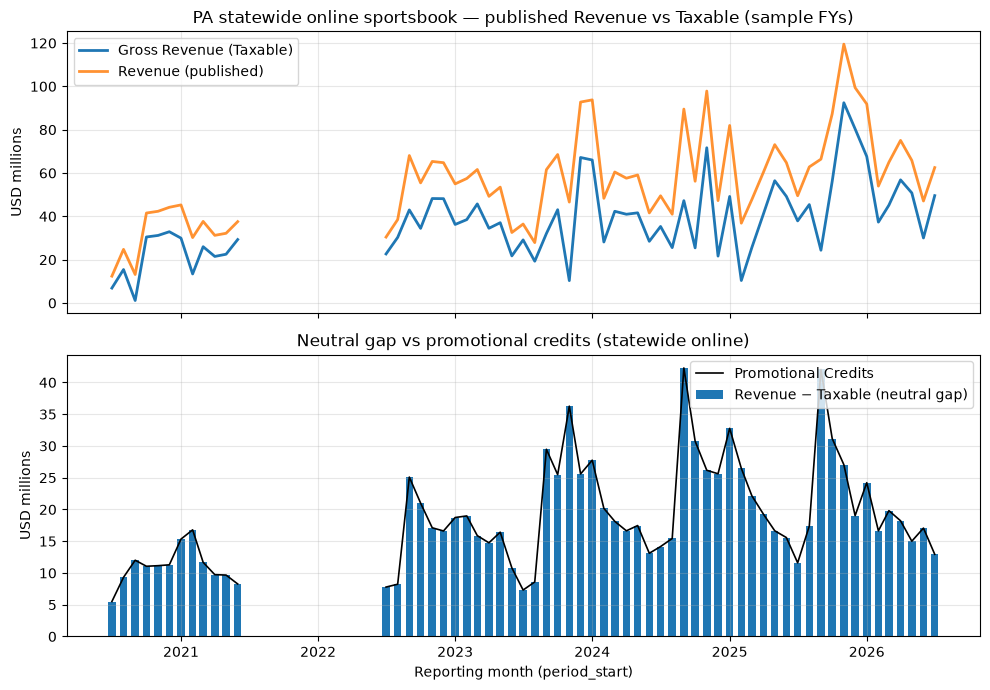

Statewide online diagnostic table (tail):


,source_fy,period_start,revenue,promotional_credits,gross_revenue_taxable,revenue_minus_taxable
2025-08-01,FY 2025/2026,2025-08-01,6.280615e+07,17382545.86,45423605.33,17382545.86
2025-09-01,FY 2025/2026,2025-09-01,6.639747e+07,42043915.55,24353553.06,42043915.55
2025-10-01,FY 2025/2026,2025-10-01,8.732120e+07,31169901.31,56151294.79,31169901.30
2025-11-01,FY 2025/2026,2025-11-01,1.194906e+08,27056624.90,92433985.52,27056624.90
2025-12-01,FY 2025/2026,2025-12-01,9.940310e+07,19025504.05,80377594.55,19025504.05
2026-01-01,FY 2025/2026,2026-01-01,9.184174e+07,24217864.11,67623871.74,24217864.11
2026-02-01,FY 2025/2026,2026-02-01,5.396913e+07,16638392.32,37330735.56,16638392.32
2026-03-01,FY 2025/2026,2026-03-01,6.497171e+07,19813170.89,45158536.06,19813170.89
2026-04-01,FY 2025/2026,2026-04-01,7.505740e+07,18220037.12,56837358.41,18220037.12
2026-05-01,FY 2025/2026,2026-05-01,6.581057e+07,15006963.70,50803611.22,15006963.70


In [9]:
statewide_online = online[online["operator_native"].map(_normalize_label) == "grand total"].copy()
statewide_online = statewide_online.sort_values("period_start")
for c in ["revenue", "promotional_credits", "gross_revenue_taxable"]:
    statewide_online[c] = statewide_online[c].map(lambda x: float(x) if x is not None else None)

plot_df = statewide_online.dropna(subset=["gross_revenue_taxable"]).copy()
plot_df["period"] = pd.to_datetime(plot_df["period_start"])

plot_df = plot_df.set_index("period").reindex(pd.date_range(plot_df.period.min(), plot_df.period.max(), freq="MS"))
plot_df["period"] = plot_df.index
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(plot_df["period"], plot_df["gross_revenue_taxable"] / 1e6, label="Gross Revenue (Taxable)", linewidth=2)
axes[0].plot(plot_df["period"], plot_df["revenue"] / 1e6, label="Revenue (published)", linewidth=2, alpha=0.85)
axes[0].set_ylabel("USD millions")
axes[0].set_title("PA statewide online sportsbook — published Revenue vs Taxable (sample FYs)")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)

gap = plot_df["revenue"] - plot_df["gross_revenue_taxable"]
axes[1].bar(plot_df["period"], gap / 1e6, width=20, label="Revenue − Taxable (neutral gap)")
axes[1].plot(plot_df["period"], plot_df["promotional_credits"] / 1e6, color="black", linewidth=1.2, label="Promotional Credits")
axes[1].set_ylabel("USD millions")
axes[1].set_xlabel("Reporting month (period_start)")
axes[1].set_title("Neutral gap vs promotional credits (statewide online)")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)
locator = mdates.AutoDateLocator(minticks=4, maxticks=7)
axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
fig.tight_layout()
plt.show()

summary_tbl = plot_df[
    ["source_fy", "period_start", "revenue", "promotional_credits", "gross_revenue_taxable"]
].copy()
summary_tbl["revenue_minus_taxable"] = summary_tbl["revenue"] - summary_tbl["gross_revenue_taxable"]
print("Statewide online diagnostic table (tail):")
display(summary_tbl.tail(12))


## Downstream mapping conflict (`consolidate.revenue_basis` + notebook 40)

**What.** Inspect how populating `gross_revenue` interacts with consolidation labeling and notebook 40's cross-state comparison filter.

**Why.** Preserving a published PGCB field and approving cross-state comparability are **separate decisions**. A storage write is not automatically a cohort-eligibility decision.

**Assumptions.** Current production code paths remain unchanged in this notebook. We document conflict only; we do **not** implement an eligibility framework, schema change, or special case.

**Inspect.** Exact `revenue_basis` priority and notebook 40 inclusion rules; smallest implementation alternatives and tradeoffs.


In [10]:
import inspect
from variant_gaming.consolidate import revenue_basis, revenue_amount

print("=== consolidate.revenue_basis (production) ===")
print(inspect.getsource(revenue_basis))
print(inspect.getsource(revenue_amount))

print(
    "Implication: if PA online rows gain a non-null gross_revenue while taxable_revenue remains "
    "populated, revenue_basis(row) returns \"GGR\" because gross_revenue is checked first. "
    "The observation is then labeled GGR for consolidation exports regardless of whether PGCB "
    "'Revenue' is definitionally comparable to other states' GGR."
)

demo = pd.DataFrame(
    [
        {
            "case": "status_quo_PA_online",
            "gross_revenue": pd.NA,
            "adjusted_revenue": pd.NA,
            "taxable_revenue": 1_000_000.0,
            "net_proceeds": pd.NA,
        },
        {
            "case": "naive_Revenue_into_gross_revenue",
            "gross_revenue": 1_200_000.0,
            "adjusted_revenue": pd.NA,
            "taxable_revenue": 1_000_000.0,
            "net_proceeds": pd.NA,
        },
    ]
)
demo["revenue_basis"] = demo.apply(revenue_basis, axis=1)
demo["revenue_amount"] = demo.apply(revenue_amount, axis=1)
print("Illustrative labeling effect (synthetic numbers):")
display(demo)

print("\n=== notebook 40 comparison filter (handle-plus-GGR cohort) ===")
print(
    "From notebooks/40_sqlite_ggr_analysis.ipynb — comparable multi-state online sportsbooks:\n"
    "  Inclusion rules (all required):\n"
    "  - vertical == online sports betting\n"
    "  - frequency == monthly\n"
    "  - revenue_basis == 'GGR'\n"
    "  - positive, non-null handle\n"
    "  - non-null revenue\n"
    "Therefore a naive Revenue → gross_revenue write would automatically make PA eligible for that "
    "GGR cohort via revenue_basis, without any separate comparability review."
)

print("\n=== Decision separation ===")
print("1. Field preservation: may PGCB Online 'Revenue' be retained as a published native field?")
print("2. Cross-state comparability: may that field enter GGR cohorts / be labeled revenue_basis=GGR?")
print("These are separate. Arithmetic identity alone does not answer (2).")

print("\n=== Smallest implementation alternatives (document only — do not implement) ===")
alternatives = pd.DataFrame(
    [
        {
            "alt": "A. Status quo",
            "change": "Keep taxable only; leave gross_revenue null",
            "pros": "No false GGR labeling; notebook 40 cohort unchanged",
            "cons": "Drops a published native Online line",
        },
        {
            "alt": "B. Naive Revenue → gross_revenue",
            "change": "Parser writes Revenue into gross_revenue; taxable unchanged",
            "pros": "Minimal parser diff; preserves published field in existing column",
            "cons": "Auto-labels PA as GGR via revenue_basis; notebook 40 would include PA without comparability decision — NOT safe standalone",
        },
        {
            "alt": "C. Preserve field, defer eligibility",
            "change": "Retain Revenue out-of-band / non-cohort until labeling policy is decided",
            "pros": "Avoids silent GGR promotion; keeps evidence",
            "cons": "Requires an explicit later decision; not implemented here (no new schema/framework in this notebook)",
        },
        {
            "alt": "D. Wait for definitional evidence",
            "change": "No storage change until PGCB/statute mapping of Revenue vs taxable vs statutory gross is resolved",
            "pros": "Highest definitional safety",
            "cons": "Continues to omit a published line from structured storage",
        },
    ]
)
display(alternatives)
print(
    "Provisional stance for this notebook: Revenue → gross_revenue remains a HYPOTHESIS only. "
    "It is not currently a safe standalone production change because of the GGR auto-label path."
)


=== consolidate.revenue_basis (production) ===
def revenue_basis(row: pd.Series) -> str | None:
    """Pick a single labeled revenue basis; never mix definitions silently."""
    if pd.notna(row.get("gross_revenue")):
        return "GGR"
    if pd.notna(row.get("adjusted_revenue")):
        return "AGR"
    if pd.notna(row.get("taxable_revenue")):
        return "taxable_revenue"
    if pd.notna(row.get("net_proceeds")):
        return "net_proceeds"
    return None

def revenue_amount(row: pd.Series) -> float | None:
    basis = revenue_basis(row)
    if basis == "GGR":
        return float(row["gross_revenue"])
    if basis == "AGR":
        return float(row["adjusted_revenue"])
    if basis == "taxable_revenue":
        return float(row["taxable_revenue"])
    if basis == "net_proceeds":
        return float(row["net_proceeds"])
    return None

Implication: if PA online rows gain a non-null gross_revenue while taxable_revenue remains populated, revenue_basis(row) returns "GGR" bec

,case,gross_revenue,adjusted_revenue,taxable_revenue,net_proceeds,revenue_basis,revenue_amount
0,status_quo_PA_online,<NA>,<NA>,1000000.0,<NA>,taxable_revenue,1000000.0
1,naive_Revenue_into_gross_revenue,1200000.0,<NA>,1000000.0,<NA>,GGR,1200000.0



=== notebook 40 comparison filter (handle-plus-GGR cohort) ===
From notebooks/40_sqlite_ggr_analysis.ipynb — comparable multi-state online sportsbooks:
  Inclusion rules (all required):
  - vertical == online sports betting
  - frequency == monthly
  - revenue_basis == 'GGR'
  - positive, non-null handle
  - non-null revenue
Therefore a naive Revenue → gross_revenue write would automatically make PA eligible for that GGR cohort via revenue_basis, without any separate comparability review.

=== Decision separation ===
1. Field preservation: may PGCB Online 'Revenue' be retained as a published native field?
2. Cross-state comparability: may that field enter GGR cohorts / be labeled revenue_basis=GGR?
These are separate. Arithmetic identity alone does not answer (2).

=== Smallest implementation alternatives (document only — do not implement) ===


,alt,change,pros,cons
0,A. Status quo,Keep taxable only; leave gross_revenue null,No false GGR labeling; notebook 40 cohort unchanged,Drops a published native Online line
1,B. Naive Revenue → gross_revenue,Parser writes Revenue into gross_revenue; taxable unchanged,Minimal parser diff; preserves published field in existing column,Auto-labels PA as GGR via revenue_basis; notebook 40 would include PA without comparability decision — NOT safe standalone
2,"C. Preserve field, defer eligibility",Retain Revenue out-of-band / non-cohort until labeling policy is decided,Avoids silent GGR promotion; keeps evidence,Requires an explicit later decision; not implemented here (no new schema/framework in this notebook)
3,D. Wait for definitional evidence,No storage change until PGCB/statute mapping of Revenue vs taxable vs statutory gross is resolved,Highest definitional safety,Continues to omit a published line from structured storage


Provisional stance for this notebook: Revenue → gross_revenue remains a HYPOTHESIS only. It is not currently a safe standalone production change because of the GGR auto-label path.


## Final validation and recommendation

**What.** Record findings, reconciliation results, semantic layers, downstream conflict, coverage limits, and a go/no-go for **research review** (not production merge).

**Why.** This notebook is methodology research — it must not alter shared contracts, schema, collectors, or eligibility frameworks.

**Assumptions.** Recommendation concerns readiness for research review and the specific decisions still required before any production implementation.

**Inspect.** Notebook-local failure examples below cover a genuine zero month, all-blank months, formula-only templates, conflicting cells, missing promotional credits, and negative values. Counts do not establish operator activity or legal comparability.


In [11]:
# Small synthetic checks exercise decisions, not production/database behavior.
period = "2026-08-01"
test_long = pd.DataFrame([
    dict(operator_native="EXAMPLE", channel="online", period_start=period,
         metric="revenue", value=Decimal(0), raw_kind="literal"),
    dict(operator_native="GRAND TOTAL", channel="online", period_start=period,
         metric="revenue", value=Decimal(0), raw_kind="formula"),
])
test_wide = pd.DataFrame({"period_start": [period, period]})
for detail_kind, detail_value, control_kind, control_value, expected in [
    ("literal", Decimal(0), "formula", Decimal(0), "observed_reporting"),
    ("blank", None, "formula", Decimal(0), "template_placeholder"),
    ("blank", None, "blank", None, "unknown_unreported"),
    ("blank", None, "formula", None, "unknown_unreported"),
]:
    example = test_long.copy()
    example.loc[0, ["raw_kind", "value"]] = [detail_kind, detail_value]
    example.loc[1, ["raw_kind", "value"]] = [control_kind, control_value]
    classes, excluded = classify_template_periods(test_wide, example, source_fy="synthetic", source_file="synthetic")
    assert classes.classification.item() == expected
    assert (period in excluded) == (expected != "observed_reporting")

conflict = pd.concat([test_long.iloc[:1], test_long.iloc[:1].assign(value=Decimal(1))])
try:
    audit_long_form_keys(conflict, source_file="synthetic conflicting cells", source_fy="synthetic")
    raise AssertionError("Conflicting keys must not be silently collapsed")
except RuntimeError:
    print("Expected duplicate-key failure caught; no source records were discarded.")

example = dict(source_fy="synthetic", source_url="synthetic", source_file="synthetic",
               operator_native="EXAMPLE", channel="online", period_start=period,
               revenue=Decimal(10), promotional_credits=None, gross_revenue_taxable=Decimal(10))
result = reconcile_identity(pd.DataFrame([example]), "online").iloc[0]
assert result.status == "unevaluable" and pd.isna(result.abs_diff)
example.update(revenue=Decimal(-10), promotional_credits=Decimal(0), gross_revenue_taxable=Decimal(-10))
result = reconcile_identity(pd.DataFrame([example]), "online").iloc[0]
assert result.status == "pass" and result.revenue == -10
assert to_decimal(0) == 0 and to_decimal(None) is None and to_decimal(float("nan")) is None
print("Notebook-local zero/template/missing/duplicate/negative assertions passed.")

findings = {
    "question": "Does PA publish a gross sportsbook revenue measure separable from taxable?",
    "short_answer": (
        "Online (and Total) sections publish a native 'Revenue' line alongside "
        "'Gross Revenue (Taxable)' and 'Promotional Credits'. Retail generally publishes taxable without Revenue/Promo. "
        "Arithmetic supports Revenue − Promo = Taxable on Online rows where all three inputs are published. "
        "That does NOT by itself establish that workbook Revenue equals statutory gross or cross-state GGR."
    ),
    "sample_grain": "six fiscal-year workbooks with monthly columns (not six independent monthly files)",
    "online_identity_n_total": int(online_counts["n_total"]),
    "online_identity_n_evaluable": int(online_counts["n_evaluable"]),
    "online_identity_n_pass": int(online_counts["n_pass"]),
    "online_identity_n_fail": int(online_counts["n_fail"]),
    "online_identity_n_unevaluable": int(online_counts["n_unevaluable"]),
    "online_identity_n_operator_detail_evaluable": int(online_ops_counts["n_evaluable"]),
    "online_identity_n_grand_total_control_evaluable": int(online_ctrl_counts["n_evaluable"]),
    "online_identity_failures": int(online_counts["n_fail"]),
    "online_identity_max_abs_diff": online_counts["max_abs_diff"],
    "total_identity_n_evaluable": int(total_counts["n_evaluable"]),
    "total_identity_failures": int(total_counts["n_fail"]),
    "total_identity_n_unevaluable": int(total_counts["n_unevaluable"]),
    "total_identity_max_abs_diff": total_counts["max_abs_diff"],
    "total_failures_also_fail_online": int(
        (
            total_identity.loc[total_identity["status"] == "fail"]
            .merge(
                online_identity,
                on=["source_fy", "operator_native", "period_start"],
                how="left",
                suffixes=("_total", "_online"),
            )["status_online"]
            == "fail"
        ).sum()
    )
    if len(total_identity) and (total_identity["status"] == "fail").any()
    else 0,
    "tax_monthly_34pct_failures_at_0_01": int((~tax_df["pass_state_tol_0_01"]).sum()) if len(tax_df) else None,
    "tax_monthly_34pct_max_abs_diff": float(tax_df["abs_state_diff"].max()) if len(tax_df) else None,
    "parser_taxable_max_abs_diff_vs_research": float(both["taxable_diff"].abs().max()) if len(both) else None,
    "header_periods_min": str(header_coverage_df["header_period_min"].min()) if len(header_coverage_df) else None,
    "header_periods_max": str(header_coverage_df["header_period_max"].max()) if len(header_coverage_df) else None,
    "observed_reporting_periods_min": str(observations["period_start"].min()) if len(observations) else None,
    "observed_reporting_periods_max": str(observations["period_start"].max()) if len(observations) else None,
    "sample_periods_min": str(observations["period_start"].min()) if len(observations) else None,
    "sample_periods_max": str(observations["period_start"].max()) if len(observations) else None,
    "latest_completed_month_in_latest_fy": str(latest_period),
    "parser_only_rows": len(left_only),
    "research_only_rows": len(right_only),
    "research_only_classifications": unmatched.reason.value_counts().to_dict(),
    "zero_rows_are_activity_evidence": False,
    "production_db_compared": False,
    "production_db_comparison_note": (
        "No DB comparison is performed regardless of whether data/gaming.sqlite exists locally; "
        "the database is neither opened nor modified."
    ),
    "downstream_conflict": (
        "Populating gross_revenue causes consolidate.revenue_basis to return GGR; "
        "notebook 40 handle+GGR cohort would then include PA without a separate comparability decision."
    ),
}

print("FINDINGS")
for k, v in findings.items():
    print(f"  {k}: {v}")

print("\nVALIDATED (workbook / parser evidence)")
print("  - Six FY Excel sports summaries expose monthly Online vs Retail vs Total sections.")
print("  - Online publishes Revenue, Promotional Credits, and Gross Revenue (Taxable).")
print("  - Matched parser values agree within cents; row sets differ (see research-only classifications).")
print(
    f"  - Online arithmetic identity holds within $0.01 for "
    f"{online_counts['n_pass']}/{online_counts['n_evaluable']} evaluable Online cells "
    f"(unevaluable={online_counts['n_unevaluable']}; missing inputs not imputed)."
)
print("  - Total-section failures (if any) are displayed with provenance and do not automatically refute Online rows.")
print("  - Long-form duplicate keys were audited before pivot; ambiguous cells would fail the notebook.")

print("\nOFFICIAL DEFINITION (cited docs)")
print("  - Statutory/regulatory 'gross sports wagering revenue' is the 34% tax base definition.")
print("  - Workbook footnote addresses Handle* timing vs Gross Revenue; it does not define bare 'Revenue'.")

print("\nUNCERTAIN (interpretation)")
print("  - Whether workbook 'Revenue' equals statutory gross sports wagering revenue.")
print("  - Whether 'Revenue' is cross-state GGR-comparable.")
print("  - Exact components of Promotional Credits (neutral label retained).")
print("  - Publication/revision timestamps remain unknown (retrieved_at_utc may be null; mtime is not retrieval).")
print("  - Full-history layout stability beyond these six FY files.")

print("\nEDGE CASES")
print("  - FY workbook sheet titles can mismatch filename year (month headers still govern).")
print("  - Total-section identity outliers exist in source (see full failure table above).")
print("  - Retail omits Revenue/Promo lines — do not invent them; identity is unevaluable without promo.")
print("  - Negative taxable/revenue months occur and must be preserved.")
print("  - Legitimate zero observations in reported months are preserved; blank-input/formula-control templates excluded; all-missing months remain unknown.")
print("  - Operator label spelling/case drifts across years.")
print("  - Monthly state tax is not always exact round(month_taxable*0.34,¢); do not reverse tax.")

print("\nCOVERAGE / SAMPLING LIMITS")
print("  - Sample = six fiscal-year workbooks, not six independent monthly report files.")
print(
    f"  - Header/template period_max={findings['header_periods_max']}; "
    f"observed reporting period_max={findings['observed_reporting_periods_max']}."
)
print("  - Online reconciliation n_evaluable counts cells with all three of Revenue/Promo/Taxable; includes GRAND TOTAL controls.")
print("  - Do not treat repeated totals or overlapping workbook observations as independent validation evidence.")
print("  - Latest FY sample may contain only the first completed month(s) at retrieval time.")
print("  - Tracked fixture remains a test input until provenance is established.")

print("\nREPORTED vs DERIVED")
print("  - Revenue, Promotional Credits, Gross Revenue (Taxable), taxes: REPORTED.")
print("  - Revenue − Taxable gap: DERIVED diagnostic; equals Promo when identity holds.")
print("  - Tax inversion to impute gross: FORBIDDEN / not used.")
print("  - Missing Promotional Credits imputed as 0: FORBIDDEN / not used.")

print("\nDOWNSTREAM CONFLICT")
print("  - Field preservation ≠ cohort eligibility.")
print("  - Revenue → gross_revenue is NOT currently a safe standalone production change.")
print("  - Mapping stays provisional until meaning + downstream eligibility are resolved.")
print("  - No eligibility framework / schema / special case implemented in this notebook.")

print("\nMINIMAL ALTERNATIVES (document only)")
print("  A. Status quo (taxable only)")
print("  B. Naive Revenue → gross_revenue (unsafe standalone due to GGR auto-label)")
print("  C. Preserve field while deferring eligibility/labeling decision")
print("  D. Wait for stronger definitional evidence before any storage change")

recommendation = "ready for research review"
print("\nRECOMMENDATION:", recommendation)
print(
    "Before production implementation, research review must specifically decide:\n"
    "  (1) whether to retain PGCB Online 'Revenue' as a preserved published field at all;\n"
    "  (2) whether that field may populate gross_revenue given consolidate.revenue_basis → GGR;\n"
    "  (3) whether PA may enter notebook 40's handle+GGR cohort / other cross-state GGR uses;\n"
    "  (4) what evidence would equate workbook 'Revenue' with statutory gross (arithmetic alone is insufficient).\n"
    "Until those decisions are made, do not implement production parser/schema/eligibility changes."
)

print(
    "\nConfirmed: no database comparison performed "
    f"(local gaming.sqlite exists={ (ROOT / 'data' / 'gaming.sqlite').exists() }; neither opened nor modified)."
)



DUPLICATE/CONFLICTING long-form keys in synthetic conflicting cells (n=1):


,source_fy,source_file,operator_native,channel,period_start,metric,n_cells,distinct_values,ambiguous,values_preview
0,synthetic,synthetic conflicting cells,EXAMPLE,online,2026-08-01,revenue,2,"[0, 1]",True,"[0.0, 1.0]"


Expected duplicate-key failure caught; no source records were discarded.
Notebook-local zero/template/missing/duplicate/negative assertions passed.
FINDINGS
  question: Does PA publish a gross sportsbook revenue measure separable from taxable?
  short_answer: Online (and Total) sections publish a native 'Revenue' line alongside 'Gross Revenue (Taxable)' and 'Promotional Credits'. Retail generally publishes taxable without Revenue/Promo. Arithmetic supports Revenue − Promo = Taxable on Online rows where all three inputs are published. That does NOT by itself establish that workbook Revenue equals statutory gross or cross-state GGR.
  sample_grain: six fiscal-year workbooks with monthly columns (not six independent monthly files)
  online_identity_n_total: 1146
  online_identity_n_evaluable: 1140
  online_identity_n_pass: 1140
  online_identity_n_fail: 0
  online_identity_n_unevaluable: 6
  online_identity_n_operator_detail_evaluable: 1079
  online_identity_n_grand_total_control_evaluabl

### Key findings (executive)

1. **Separate published line exists (Online).** PGCB online sports worksheets publish `Revenue` beside `Gross Revenue (Taxable)` and `Promotional Credits`.
2. **Arithmetic (workbook-established).** Evaluable Online cells (all three of Revenue / Promo / Taxable published) satisfy `Revenue − Promotional Credits = Gross Revenue (Taxable)` within $0.01. Missing promo is **unevaluable** (not imputed as zero). This is **not** by itself an official definition that workbook `Revenue` equals statutory gross.
3. **Sample grain / coverage.** Evidence comes from **six fiscal-year workbooks** with monthly columns. Header/template month grids can extend to FY-end (e.g. 2027-06); **observed reporting** coverage stops at the latest completed month with statewide activity. The Online reconciliation denominator is recomputed from evaluable workbook-scoped cells (operator detail + GRAND TOTAL controls), not a forced prior constant and not N independent monthly files.
4. **Total-section exceptions.** All Total-channel identity failures are listed with URL/workbook/sheet/period/entity/values/residual. They do **not** generalize Online validation to retail or combined totals.
5. **Downstream conflict.** Writing `Revenue` into `gross_revenue` would auto-label PA as `revenue_basis == "GGR"` via `consolidate.revenue_basis`, and notebook 40's handle+GGR filter would treat it as comparable GGR. **Not a safe standalone change.**
6. **Recommendation.** **Ready for research review.** Production implementation requires explicit decisions on field preservation vs GGR labeling/eligibility; mapping remains provisional.
